Performance Sensitivity Analysis

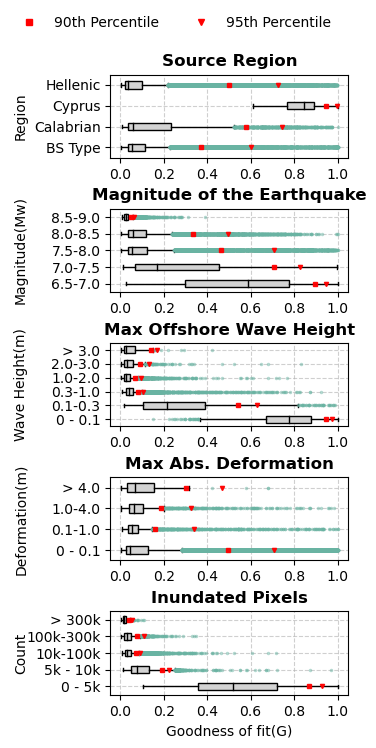

In [59]:
import matplotlib.pyplot as plt
import contextily as cx
import pandas as pd
import numpy as np

# Load file
MLDir = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami' 
reg = 'CT'
if reg == 'CT':
    columnname = str(38)
    list_size = ['225', '529','892','1658','3454','7071']  
elif reg == 'SR':
    columnname = str(54)
    list_size = ['228', '550' ,'961','1773','3669','6941']

train_size = list_size[3]
eve_perf = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_compile_combined.csv')

eve_perf = eve_perf[eve_perf['split']=='test'] #filter test
# eve_perf = eve_perf[eve_perf['max_off']>0.1] #filter as training set
# eve_perf = eve_perf[eve_perf['l2n'] > 0.1]
# eve_perf = eve_perf[eve_perf['true'] > 10000]

mag_edges = np.arange(6.5, 9.5, 0.5)
dz_edges = [0,0.1,1,4,5]
area_edges = [0,5000,10000,100000,300000,600000]

eve_perf['mag_bin'] = pd.cut(eve_perf['Mag'], mag_edges)
eve_perf['dz_bin'] = pd.cut(eve_perf['max_absdz'], dz_edges)
eve_perf['area_bin'] = pd.cut(eve_perf['true'], area_edges)

# Create the figure and axes for each variable
fig, axs = plt.subplots(5,1,figsize=(3.5, 7))

# Titles for each subplot
titles = ['Source Region','Magnitude of the Earthquake','Max Offshore Wave Height','Max Abs. Deformation','Inundated Pixels']
yaxis_label= ['Region','Magnitude(Mw)','Wave Height(m)','Deformation(m)','Count']
eve_perf.boxplot(column='g', by='SR', vert=False, showfliers=True,
                 widths=0.35, patch_artist=True, ax=axs[0], 
                 flierprops=dict(marker='o', markerfacecolor='#69b3a2', markersize=2.5, markeredgecolor='none',alpha=0.5),
                 boxprops = dict(facecolor='lightgrey', color='black'),whiskerprops = dict(color='black', linewidth=1),
                 medianprops = dict(color='black', linewidth=1), capprops = dict(color='black', linewidth=1)
                 )
percentiles = [ 90, 95]
markers = ['s', 'v', 'o']
grouped = eve_perf.groupby('SR')['g']
for i, (label, group) in enumerate(grouped):
    perc_vals = np.percentile(group.values , percentiles)
    for j, p_val in enumerate(perc_vals):
        axs[0].plot(p_val, i+1, marker=markers[j], color='red', markersize=3, alpha=0.95)


yticklabels = ['BS Type','Calabrian','Cyprus','Hellenic']
axs[0].set_yticklabels(yticklabels)

eve_perf.boxplot(column='g', by='mag_bin', vert=False, showfliers=True,
                 widths=0.4, patch_artist=True, ax=axs[1],                
                 flierprops=dict(marker='o', markerfacecolor='#69b3a2', markersize=2.5, markeredgecolor='none',alpha=0.5),
                 boxprops = dict(facecolor='lightgrey', color='black'),whiskerprops = dict(color='black', linewidth=1),
                 medianprops = dict(color='black', linewidth=1), capprops = dict(color='black', linewidth=1)
                 )
grouped = eve_perf.groupby('mag_bin')['g']
for i, (label, group) in enumerate(grouped):
    perc_vals = np.percentile(group.values , percentiles)
    for j, p_val in enumerate(perc_vals):
        axs[1].plot(p_val, i+1, marker=markers[j], color='red', markersize=3, alpha=0.95)
yticklabels = ['6.5-7.0','7.0-7.5','7.5-8.0','8.0-8.5','8.5-9.0']
axs[1].set_yticklabels(yticklabels)

# Plot horizontal boxplots
eve_perf.boxplot(column='g', by='max_off_bin', vert=False, showfliers=True,
                 widths=0.5, patch_artist=True, ax=axs[2],
                 flierprops=dict(marker='o', markerfacecolor='#69b3a2', markersize=2.5, markeredgecolor='none',alpha=0.5),
                 boxprops = dict(facecolor='lightgrey', color='black'),whiskerprops = dict(color='black', linewidth=1),
                 medianprops = dict(color='black', linewidth=1), capprops = dict(color='black', linewidth=1)
                 )
grouped = eve_perf.groupby('max_off_bin')['g']
for i, (label, group) in enumerate(grouped):
    perc_vals = np.percentile(group.values , percentiles)
    for j, p_val in enumerate(perc_vals):
        axs[2].plot(p_val, i+1, marker=markers[j], color='red', markersize=3, alpha=0.95)                 
yticklabels = ['0 - 0.1', '0.1-0.3', '0.3-1.0', '1.0-2.0', '2.0-3.0', '> 3.0']
axs[2].set_yticklabels(yticklabels)

eve_perf.boxplot(column='g', by='dz_bin', vert=False, showfliers=True,
                 widths=0.4, patch_artist=True, ax=axs[3],
                 flierprops=dict(marker='o', markerfacecolor='#69b3a2', markersize=2.5, markeredgecolor='none',alpha=0.5),
                 boxprops = dict(facecolor='lightgrey', color='black'),whiskerprops = dict(color='black', linewidth=1),
                 medianprops = dict(color='black', linewidth=1), capprops = dict(color='black', linewidth=1)
                 )
grouped = eve_perf.groupby('dz_bin')['g']
for i, (label, group) in enumerate(grouped):
    perc_vals = np.percentile(group.values , percentiles)
    for j, p_val in enumerate(perc_vals):
        axs[3].plot(p_val, i+1, marker=markers[j], color='red', markersize=3, alpha=0.95)                 
yticklabels = ['0 - 0.1','0.1-1.0','1.0-4.0','> 4.0']
axs[3].set_yticklabels(yticklabels)

eve_perf.boxplot(column='g', by='area_bin', vert=False, showfliers=True,
                 widths=0.4, patch_artist=True, ax=axs[4],
                 flierprops=dict(marker='o', markerfacecolor='#69b3a2', markersize=2.5, markeredgecolor='none',alpha=0.5),
                 boxprops = dict(facecolor='lightgrey', color='black'),whiskerprops = dict(color='black', linewidth=1),
                 medianprops = dict(color='black', linewidth=1), capprops = dict(color='black', linewidth=1)
                 )
grouped = eve_perf.groupby('area_bin')['g']
for i, (label, group) in enumerate(grouped):
    perc_vals = np.percentile(group.values , percentiles)
    for j, p_val in enumerate(perc_vals):
        axs[4].plot(p_val, i+1, marker=markers[j], color='red', markersize=3, alpha=0.95)
yticklabels = ['0 - 5k','5k - 10k','10k-100k','100k-300k','> 300k']
axs[4].set_yticklabels(yticklabels)

# Set the titles for each subplot
for i, ax in enumerate(axs):
    ax.set_title(titles[i],fontweight='bold')
    #set ticks 0-1
    ax.set_xticks(np.arange(0,1.1,0.2))
    ax.set_ylabel(None)
    ax.text(-0.375,0.5,yaxis_label[i],rotation=90,va='center',ha='center',transform=ax.transAxes)
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.set_xlabel('Goodness of fit(G)')
    
# Adjust the layout to prevent overlap
plt.tight_layout(pad=0, w_pad=0.5, h_pad=0.5)
# Set the main title for the figure
fig.suptitle(None)

import matplotlib.lines as mlines

# Create legend handles for 90th and 95th percentiles
legend_handles = [
    mlines.Line2D([], [], color='red', marker='s', linestyle='None', markersize=5, label='90th Percentile'),
    mlines.Line2D([], [], color='red', marker='v', linestyle='None', markersize=5, label='95th Percentile'),
]

# Add the legend at the top center
fig.legend(handles=legend_handles, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.05), frameon=False)


# Display the plot
plt.savefig(f'./boxplot_{reg}_{train_size}_g.png',dpi=300, bbox_inches='tight')
plt.show()

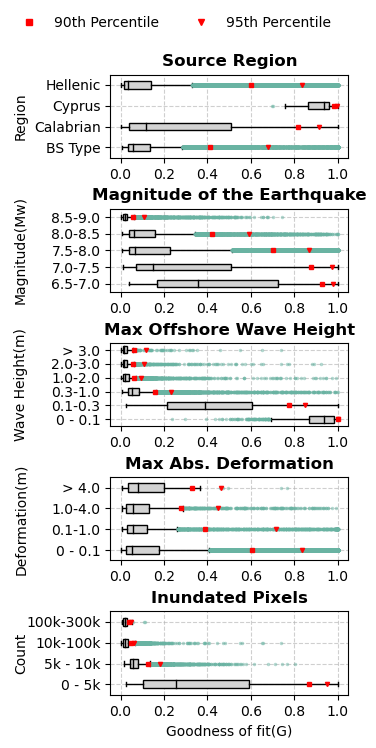

In [60]:
import matplotlib.pyplot as plt
import contextily as cx
import pandas as pd
import numpy as np

# Load file
MLDir = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami' 
reg = 'SR'
if reg == 'CT':
    columnname = str(38)
    list_size = ['225', '529','892','1658','3454','7071']  
elif reg == 'SR':
    columnname = str(54)
    list_size = ['228', '550' ,'961','1773','3669','6941']

train_size = list_size[3]
eve_perf = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_compile_combined.csv')

eve_perf = eve_perf[eve_perf['split']=='test'] #filter test
# eve_perf = eve_perf[eve_perf['max_off']>0.1] #filter as training set
# eve_perf = eve_perf[eve_perf['l2n'] > 0.1]
# eve_perf = eve_perf[eve_perf['true'] > 10000]

mag_edges = np.arange(6.5, 9.5, 0.5)
dz_edges = [0,0.1,1,4,5]
area_edges = [0,5000,10000,100000,300000]

eve_perf['mag_bin'] = pd.cut(eve_perf['Mag'], mag_edges)
eve_perf['dz_bin'] = pd.cut(eve_perf['max_absdz'], dz_edges)
eve_perf['area_bin'] = pd.cut(eve_perf['true'], area_edges)

# Create the figure and axes for each variable
fig, axs = plt.subplots(5,1,figsize=(3.5, 7))

# Titles for each subplot
titles = ['Source Region','Magnitude of the Earthquake','Max Offshore Wave Height','Max Abs. Deformation','Inundated Pixels']
yaxis_label= ['Region','Magnitude(Mw)','Wave Height(m)','Deformation(m)','Count']
eve_perf.boxplot(column='g', by='SR', vert=False, showfliers=True,
                 widths=0.35, patch_artist=True, ax=axs[0], 
                 flierprops=dict(marker='o', markerfacecolor='#69b3a2', markersize=2.5, markeredgecolor='none',alpha=0.5),
                 boxprops = dict(facecolor='lightgrey', color='black'),whiskerprops = dict(color='black', linewidth=1),
                 medianprops = dict(color='black', linewidth=1), capprops = dict(color='black', linewidth=1)
                 )
percentiles = [ 90, 95]
markers = ['s', 'v', 'o']
grouped = eve_perf.groupby('SR')['g']
for i, (label, group) in enumerate(grouped):
    perc_vals = np.percentile(group.values , percentiles)
    for j, p_val in enumerate(perc_vals):
        axs[0].plot(p_val, i+1, marker=markers[j], color='red', markersize=3, alpha=0.95)


yticklabels = ['BS Type','Calabrian','Cyprus','Hellenic']
axs[0].set_yticklabels(yticklabels)

eve_perf.boxplot(column='g', by='mag_bin', vert=False, showfliers=True,
                 widths=0.4, patch_artist=True, ax=axs[1],                
                 flierprops=dict(marker='o', markerfacecolor='#69b3a2', markersize=2.5, markeredgecolor='none',alpha=0.5),
                 boxprops = dict(facecolor='lightgrey', color='black'),whiskerprops = dict(color='black', linewidth=1),
                 medianprops = dict(color='black', linewidth=1), capprops = dict(color='black', linewidth=1)
                 )
grouped = eve_perf.groupby('mag_bin')['g']
for i, (label, group) in enumerate(grouped):
    perc_vals = np.percentile(group.values , percentiles)
    for j, p_val in enumerate(perc_vals):
        axs[1].plot(p_val, i+1, marker=markers[j], color='red', markersize=3, alpha=0.95)
yticklabels = ['6.5-7.0','7.0-7.5','7.5-8.0','8.0-8.5','8.5-9.0']
axs[1].set_yticklabels(yticklabels)

# Plot horizontal boxplots
eve_perf.boxplot(column='g', by='max_off_bin', vert=False, showfliers=True,
                 widths=0.5, patch_artist=True, ax=axs[2],
                 flierprops=dict(marker='o', markerfacecolor='#69b3a2', markersize=2.5, markeredgecolor='none',alpha=0.5),
                 boxprops = dict(facecolor='lightgrey', color='black'),whiskerprops = dict(color='black', linewidth=1),
                 medianprops = dict(color='black', linewidth=1), capprops = dict(color='black', linewidth=1)
                 )
grouped = eve_perf.groupby('max_off_bin')['g']
for i, (label, group) in enumerate(grouped):
    perc_vals = np.percentile(group.values , percentiles)
    for j, p_val in enumerate(perc_vals):
        axs[2].plot(p_val, i+1, marker=markers[j], color='red', markersize=3, alpha=0.95)                 
yticklabels = ['0 - 0.1', '0.1-0.3', '0.3-1.0', '1.0-2.0', '2.0-3.0', '> 3.0']
axs[2].set_yticklabels(yticklabels)

eve_perf.boxplot(column='g', by='dz_bin', vert=False, showfliers=True,
                 widths=0.4, patch_artist=True, ax=axs[3],
                 flierprops=dict(marker='o', markerfacecolor='#69b3a2', markersize=2.5, markeredgecolor='none',alpha=0.5),
                 boxprops = dict(facecolor='lightgrey', color='black'),whiskerprops = dict(color='black', linewidth=1),
                 medianprops = dict(color='black', linewidth=1), capprops = dict(color='black', linewidth=1)
                 )
grouped = eve_perf.groupby('dz_bin')['g']
for i, (label, group) in enumerate(grouped):
    perc_vals = np.percentile(group.values , percentiles)
    for j, p_val in enumerate(perc_vals):
        axs[3].plot(p_val, i+1, marker=markers[j], color='red', markersize=3, alpha=0.95)                 
yticklabels = ['0 - 0.1','0.1-1.0','1.0-4.0','> 4.0']
axs[3].set_yticklabels(yticklabels)

eve_perf.boxplot(column='g', by='area_bin', vert=False, showfliers=True,
                 widths=0.4, patch_artist=True, ax=axs[4],
                 flierprops=dict(marker='o', markerfacecolor='#69b3a2', markersize=2.5, markeredgecolor='none',alpha=0.5),
                 boxprops = dict(facecolor='lightgrey', color='black'),whiskerprops = dict(color='black', linewidth=1),
                 medianprops = dict(color='black', linewidth=1), capprops = dict(color='black', linewidth=1)
                 )
grouped = eve_perf.groupby('area_bin')['g']
for i, (label, group) in enumerate(grouped):
    perc_vals = np.percentile(group.values , percentiles)
    for j, p_val in enumerate(perc_vals):
        axs[4].plot(p_val, i+1, marker=markers[j], color='red', markersize=3, alpha=0.95)
yticklabels = ['0 - 5k','5k - 10k','10k-100k','100k-300k']
axs[4].set_yticklabels(yticklabels)

# Set the titles for each subplot
for i, ax in enumerate(axs):
    ax.set_title(titles[i],fontweight='bold')
    #set ticks 0-1
    ax.set_xticks(np.arange(0,1.1,0.2))
    ax.set_ylabel(None)
    ax.text(-0.375,0.5,yaxis_label[i],rotation=90,va='center',ha='center',transform=ax.transAxes)
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.set_xlabel('Goodness of fit(G)')
    

# Adjust the layout to prevent overlap
plt.tight_layout(pad=0, w_pad=0.5, h_pad=0.5)
# Set the main title for the figure
fig.suptitle(None)

import matplotlib.lines as mlines

# Create legend handles for 90th and 95th percentiles
legend_handles = [
    mlines.Line2D([], [], color='red', marker='s', linestyle='None', markersize=5, label='90th Percentile'),
    mlines.Line2D([], [], color='red', marker='v', linestyle='None', markersize=5, label='95th Percentile'),
]

# Add the legend at the top center
fig.legend(handles=legend_handles, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.05), frameon=False)

# Display the plot
plt.savefig(f'./boxplot_{reg}_{train_size}_g.png',dpi=300, bbox_inches='tight')
plt.show()

Training Location Sensitivity

count 1596
count 48823
count 4538
count 90


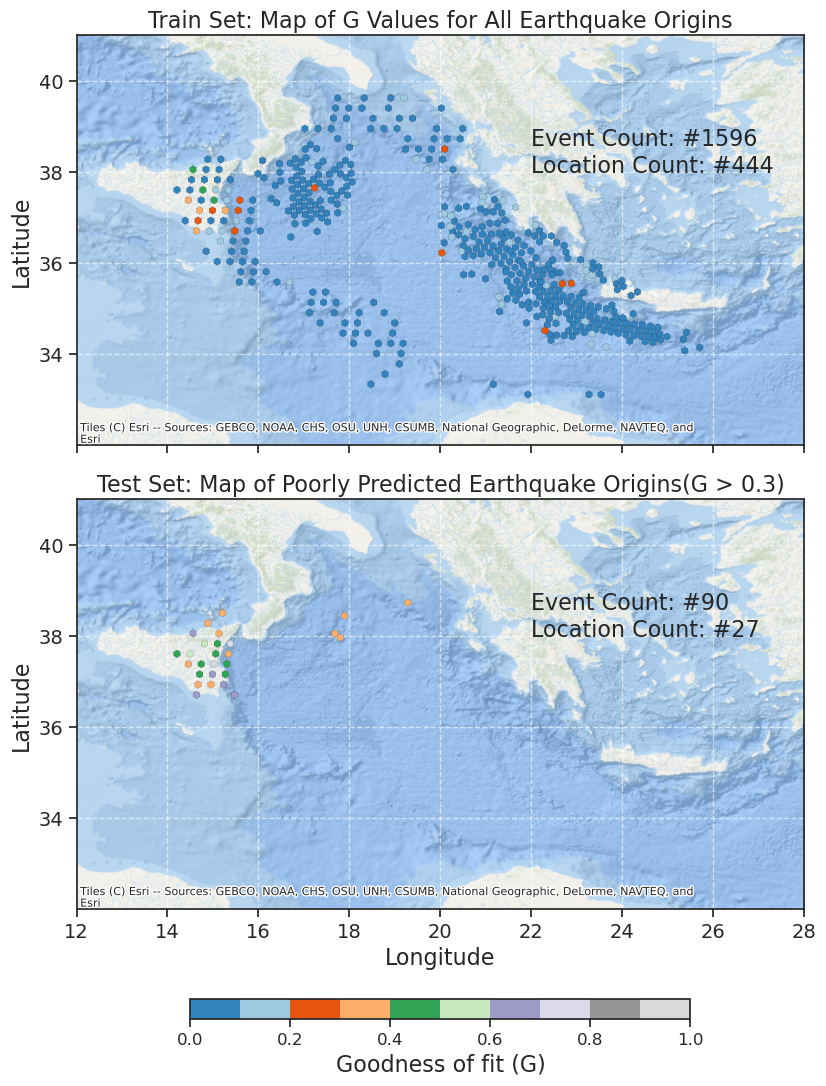

In [ ]:
import matplotlib.pyplot as plt
import contextily as cx
import pandas as pd
import numpy as np

# Load file
MLDir = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami' 
reg = 'CT'
if reg == 'CT':
    columnname = str(38)
    list_size = ['225', '529','892','1658','3454','7071']  
elif reg == 'SR':
    columnname = str(54)
    list_size = ['228', '550' ,'961','1773','3669','6941']

train_size = list_size[3]
eve_perf = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_compile_combined.csv')

eve_perf = eve_perf.sort_values(by='g', ascending=True)
eve_perf.reset_index(drop=True, inplace=True)

def filter_grids(samplelist):
    empty_table = pd.DataFrame()
    #filter rows per each grid_id, and keep row with lowest g value
    print('count',len(samplelist))
    for grid in samplelist['Location'].unique():
        samplegrid = samplelist[samplelist['Location']==grid]
        samplegrid = samplegrid.sort_values(by='g', ascending=False)
        #remove all rows except first one
        samplegrid = samplegrid.drop(samplegrid.index[1:])
        #append to empty table
        empty_table = pd.concat([empty_table,samplegrid],axis=0)
    return empty_table, len(samplelist)    

sample_train = eve_perf[eve_perf['split']=='train']
sample_train = sample_train[sample_train['max_off']>0.1]
# sample_train = sample_train[sample_train['g']>0.3]
sample_train = sample_train[sample_train['true']>5000]
sample_train,train_count = filter_grids(sample_train)

sample_test = eve_perf[eve_perf['split']=='test']
sample_test = sample_test[sample_test['max_off']>0.1]
sample_test,test_count = filter_grids(sample_test)

sample_bad = eve_perf[eve_perf['split']=='test']
sample_bad = sample_bad[sample_bad['max_off']>0.1]
sample_bad = sample_bad[sample_bad['g']>0.3]
sample_bad,bad_count = filter_grids(sample_bad)
# bad_count = len(sample_bad)

sample_bad_bigger = eve_perf[eve_perf['split']=='test']
sample_bad_bigger = sample_bad_bigger[sample_bad_bigger['max_off']>0.1]
sample_bad_bigger = sample_bad_bigger[sample_bad_bigger['g']>0.3]
sample_bad_bigger= sample_bad_bigger[sample_bad_bigger['true']>5000]
sample_bad_bigger,realbad_count = filter_grids(sample_bad_bigger)

# Create figure and subplots
fig, ax = plt.subplots(2, 1, figsize=(10, 10),sharex=True,sharey=True)
axs = ax.ravel()

# Adjust aspect ratio, limits, and add basemap
for ax in axs:
    ax.set_aspect('equal')
    ax.set_yticks([34,36,38,40])
    ax.set_xlim(12, 28)
    ax.set_ylim(32, 41)
    cx.add_basemap(ax, crs='EPSG:4326', source=cx.providers.Esri.OceanBasemap)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.tick_params(axis='both', which='minor', labelsize=14)
    if ax == axs[-1]:
        ax.set_xlabel('Longitude', fontsize=16)
    ax.set_ylabel('Latitude', fontsize=16)
    ax.grid(linestyle='--', alpha=0.6, color='white')

# Add titles to each subplot
axs[0].set_title('Train Set: Map of G Values for All Earthquake Origins', fontsize=16)
# axs[1].set_title('Test Set EQ Origins(Offshore Wave Height > 0.1m)', fontsize=20)
# axs[2].set_title('Test Set EQ Origins(G > 0.3)', fontsize=20)
axs[1].set_title('Val Set: Map of Poorly Predicted Earthquake Origins(G > 0.3)', fontsize=16)

# Function to determine marker size
def get_marker_size(sr_value):
    return 30 if sr_value == 'BS' else 30

# Define colormap
cmap = plt.get_cmap('tab20c', 10)

# Plot train events
sc_train = axs[0].scatter(sample_train['lon'], sample_train['lat'], c=sample_train['g'], s=[get_marker_size(sr) for sr in sample_train['SR']], 
                          cmap=cmap, vmin=0, vmax=1.0, marker='h', edgecolors='k', linewidth=0.1)
axs[0].text(22, 38, f'Event Count: #{str(train_count)}\nLocation Count: #{len(sample_train)}', fontsize=16)

# # Plot test events
# sc_test = axs[1].scatter(sample_test['lon'], sample_test['lat'], c=sample_test['g'], s=[get_marker_size(sr) for sr in sample_test['SR']],
#                           cmap=cmap, vmin=0, vmax=1.0, marker='h', edgecolors='k', linewidth=0.1)
# axs[1].text(25, 38, f'Event Count: #{str(test_count)}\nLocation Count: #{len(sample_test)}', fontsize=16)

# # Plot bad events
# sc_bad = axs[2].scatter(sample_bad['lon'], sample_bad['lat'], c=sample_bad['g'], s=[get_marker_size(sr) for sr in sample_bad['SR']],
#                          cmap=cmap, vmin=0, vmax=1.0, marker='h', edgecolors='k', linewidth=0.1)
# axs[2].text(25, 38, f'Event Count: #{str(bad_count)}\nLocation Count: #{len(sample_bad)}', fontsize=16)

# Plot bad events with additional filters
sc_bad_filt = axs[1].scatter(sample_bad_bigger['lon'], sample_bad_bigger['lat'], c=sample_bad_bigger['g'],
            s=[get_marker_size(sr) for sr in sample_bad_bigger['SR']], cmap=cmap, vmin=0, vmax=1.0, marker='h', edgecolors='k', linewidth=0.1)
axs[1].text(22, 38, f'Event Count: #{str(realbad_count)}\nLocation Count: #{len(sample_bad_bigger)}', fontsize=16)

plt.tight_layout()

# Add a common colorbar for the whole fig using axes transform
cbar_ax = fig.add_axes([0.25, -0.03, 0.5, 0.02])
cbar = fig.colorbar(sc_train, cax=cbar_ax, orientation='horizontal')
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Goodness of fit (G)', fontsize=16)

# Save the figure if needed
plt.savefig(f'./map_{reg}_train_test_bad_all_{train_size}.png', dpi=600, bbox_inches='tight', pad_inches=0.1)


count 1509
count 49756
count 7169
count 179


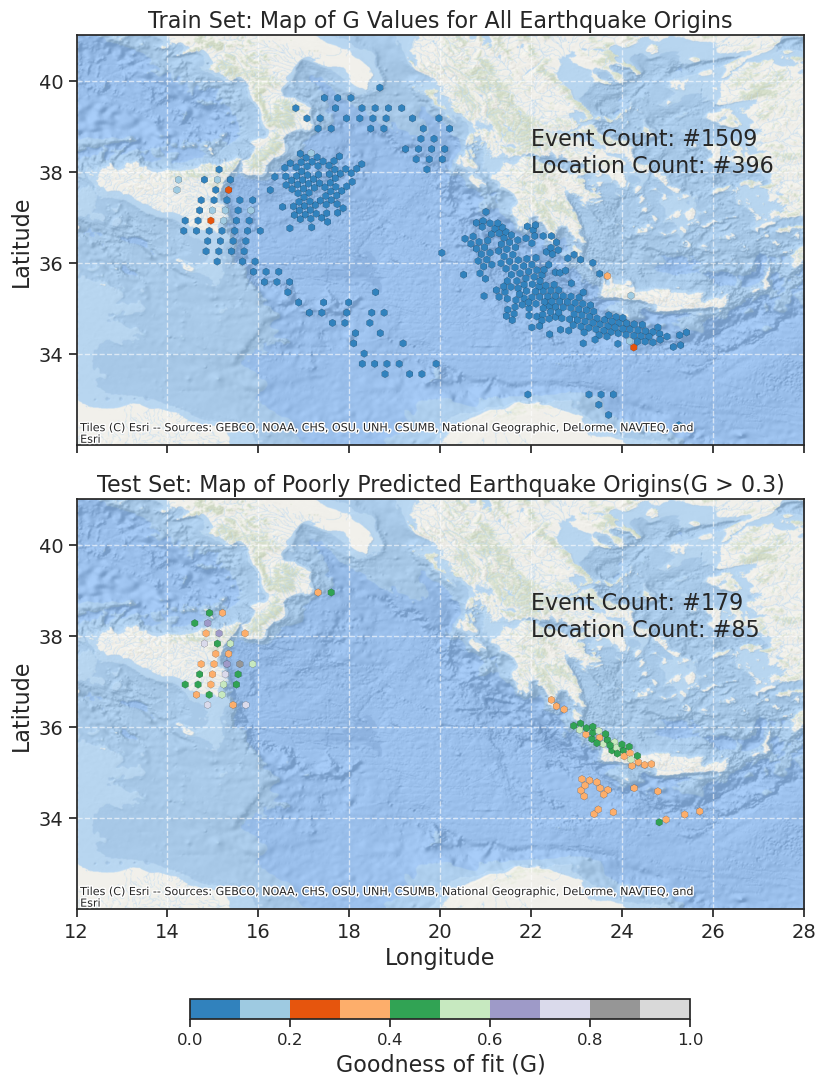

In [ ]:
import matplotlib.pyplot as plt
import contextily as cx
import pandas as pd
import numpy as np

# Load file
MLDir = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami' 
reg = 'SR'
if reg == 'CT':
    columnname = str(38)
    list_size = ['225', '529','892','1658','3454','7071']  
elif reg == 'SR':
    columnname = str(54)
    list_size = ['228', '550' ,'961','1773','3669','6941']

train_size = list_size[3]
eve_perf = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_compile_combined.csv')
eve_perf = eve_perf.sort_values(by='g', ascending=True)
eve_perf.reset_index(drop=True, inplace=True)

def filter_grids(samplelist):
    empty_table = pd.DataFrame()
    #filter rows per each grid_id, and keep row with lowest g value
    print('count',len(samplelist))
    for grid in samplelist['Location'].unique():
        samplegrid = samplelist[samplelist['Location']==grid]
        samplegrid = samplegrid.sort_values(by='g', ascending=False)
        #remove all rows except first one
        samplegrid = samplegrid.drop(samplegrid.index[1:])
        #append to empty table
        empty_table = pd.concat([empty_table,samplegrid],axis=0)
    return empty_table, len(samplelist)    

sample_train = eve_perf[eve_perf['split']=='train']
sample_train = sample_train[sample_train['max_off']>0.1]
# sample_train = sample_train[sample_train['g']>0.3]
sample_train = sample_train[sample_train['true']>5000]
sample_train,train_count = filter_grids(sample_train)

sample_test = eve_perf[eve_perf['split']=='test']
sample_test = sample_test[sample_test['max_off']>0.1]
sample_test,test_count = filter_grids(sample_test)

sample_bad = eve_perf[eve_perf['split']=='test']
sample_bad = sample_bad[sample_bad['max_off']>0.1]
sample_bad = sample_bad[sample_bad['g']>0.3]
sample_bad,bad_count = filter_grids(sample_bad)
# bad_count = len(sample_bad)

sample_bad_bigger = eve_perf[eve_perf['split']=='test']
sample_bad_bigger = sample_bad_bigger[sample_bad_bigger['max_off']>0.1]
sample_bad_bigger = sample_bad_bigger[sample_bad_bigger['g']>0.3]
sample_bad_bigger= sample_bad_bigger[sample_bad_bigger['true']>5000]
sample_bad_bigger,realbad_count = filter_grids(sample_bad_bigger)

# Create figure and subplots
fig, ax = plt.subplots(2, 1, figsize=(10, 10),sharex=True,sharey=True)
axs = ax.ravel()

# Adjust aspect ratio, limits, and add basemap
for ax in axs:
    ax.set_aspect('equal')
    ax.set_yticks([34,36,38,40])
    ax.set_xlim(12, 28)
    ax.set_ylim(32, 41)
    cx.add_basemap(ax, crs='EPSG:4326', source=cx.providers.Esri.OceanBasemap)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.tick_params(axis='both', which='minor', labelsize=14)
    if ax == axs[-1]:
        ax.set_xlabel('Longitude', fontsize=16)
    ax.set_ylabel('Latitude', fontsize=16)
    ax.grid(linestyle='--', alpha=0.6, color='white')

# Add titles to each subplot
axs[0].set_title('Train Set: Map of G Values for All Earthquake Origins', fontsize=16)
# axs[1].set_title('Test Set EQ Origins(Offshore Wave Height > 0.1m)', fontsize=20)
# axs[2].set_title('Test Set EQ Origins(G > 0.3)', fontsize=20)
axs[1].set_title('Val Set: Map of Poorly Predicted Earthquake Origins(G > 0.3)', fontsize=16)

# Function to determine marker size
def get_marker_size(sr_value):
    return 30 if sr_value == 'BS' else 30

# Define colormap
cmap = plt.get_cmap('tab20c', 10)

# Plot train events
sc_train = axs[0].scatter(sample_train['lon'], sample_train['lat'], c=sample_train['g'], s=[get_marker_size(sr) for sr in sample_train['SR']], 
                          cmap=cmap, vmin=0, vmax=1.0, marker='h', edgecolors='k', linewidth=0.1)
axs[0].text(22, 38, f'Event Count: #{str(train_count)}\nLocation Count: #{len(sample_train)}', fontsize=16)

# # Plot test events
# sc_test = axs[1].scatter(sample_test['lon'], sample_test['lat'], c=sample_test['g'], s=[get_marker_size(sr) for sr in sample_test['SR']],
#                           cmap=cmap, vmin=0, vmax=1.0, marker='h', edgecolors='k', linewidth=0.1)
# axs[1].text(25, 38, f'Event Count: #{str(test_count)}\nLocation Count: #{len(sample_test)}', fontsize=16)

# # Plot bad events
# sc_bad = axs[2].scatter(sample_bad['lon'], sample_bad['lat'], c=sample_bad['g'], s=[get_marker_size(sr) for sr in sample_bad['SR']],
#                          cmap=cmap, vmin=0, vmax=1.0, marker='h', edgecolors='k', linewidth=0.1)
# axs[2].text(25, 38, f'Event Count: #{str(bad_count)}\nLocation Count: #{len(sample_bad)}', fontsize=16)

# Plot bad events with additional filters
sc_bad_filt = axs[1].scatter(sample_bad_bigger['lon'], sample_bad_bigger['lat'], c=sample_bad_bigger['g'],
            s=[get_marker_size(sr) for sr in sample_bad_bigger['SR']], cmap=cmap, vmin=0, vmax=1.0, marker='h', edgecolors='k', linewidth=0.1)
axs[1].text(22, 38, f'Event Count: #{str(realbad_count)}\nLocation Count: #{len(sample_bad_bigger)}', fontsize=16)

plt.tight_layout()

# Add a common colorbar for the whole fig using axes transform
cbar_ax = fig.add_axes([0.25, -0.03, 0.5, 0.02])
cbar = fig.colorbar(sc_train, cax=cbar_ax, orientation='horizontal')
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Goodness of fit (G)', fontsize=16)

# Save the figure if needed
plt.savefig(f'./map_{reg}_train_test_bad_all_{train_size}.png', dpi=600, bbox_inches='tight', pad_inches=0.1)


Training Size Sensitivity

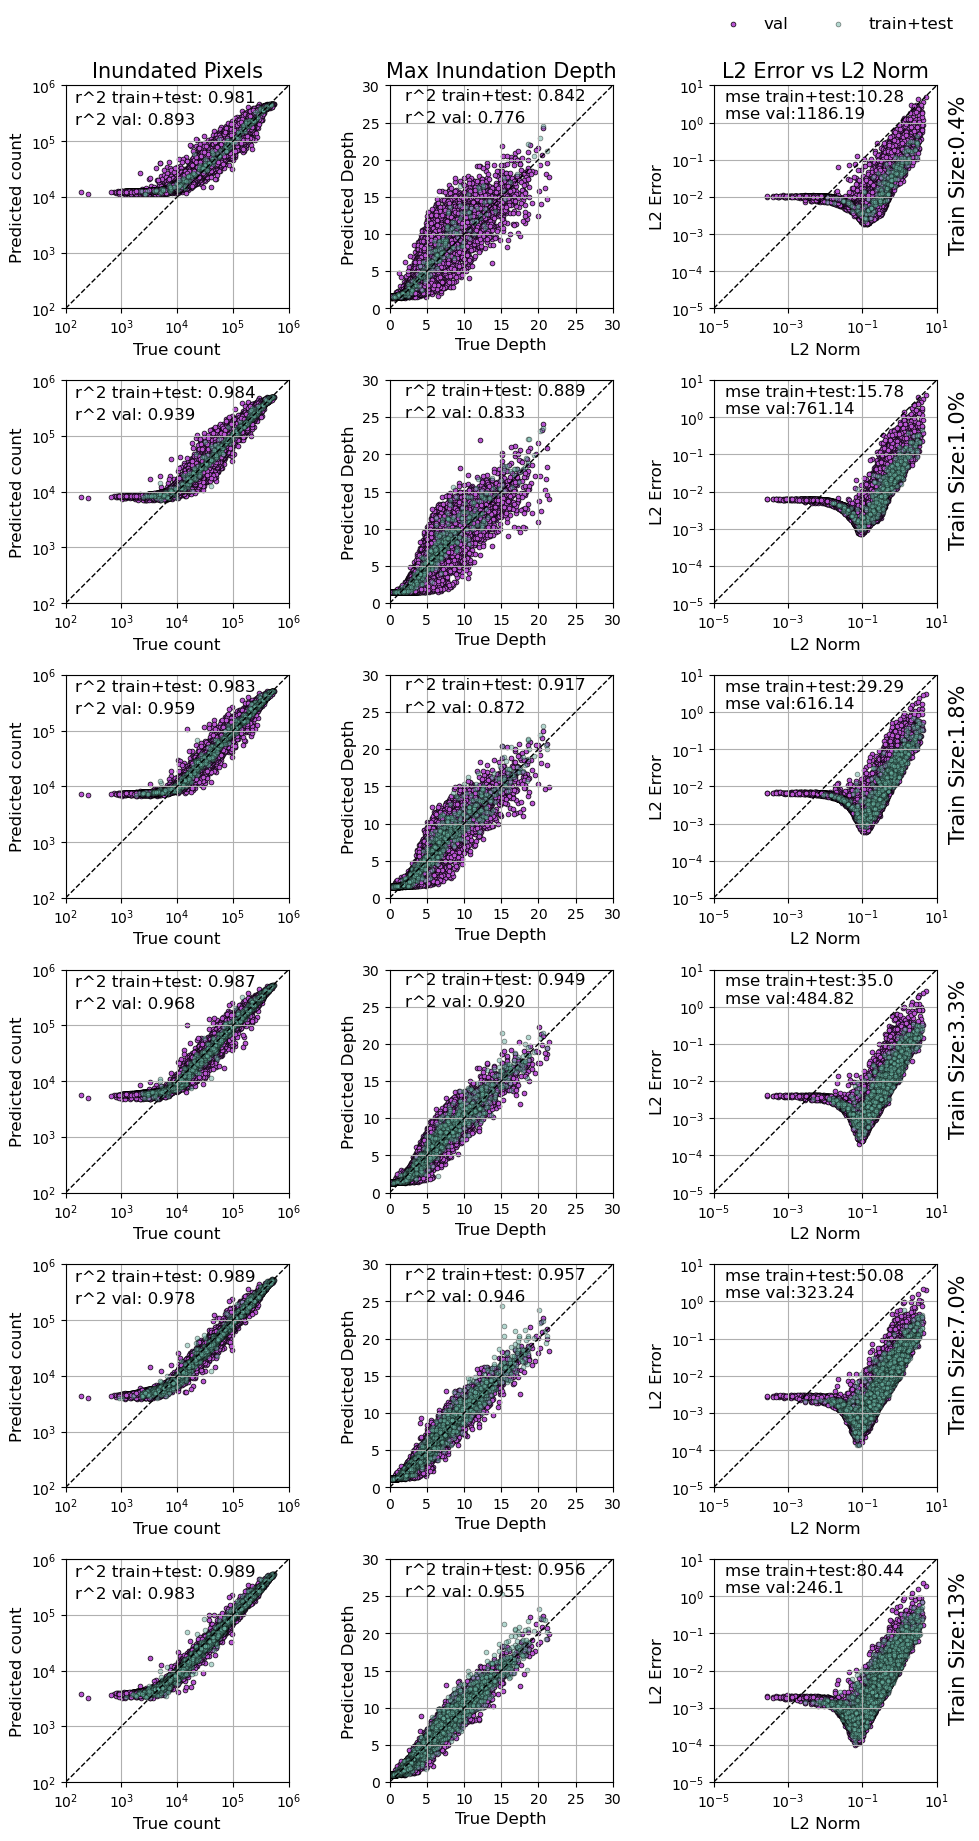

In [3]:
from sklearn.metrics import r2_score
from scipy.stats import gaussian_kde 
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from sklearn.metrics import r2_score
import xarray as xr

#select particular representative gauge
reg = 'CT'

if reg == 'CT':
    columnname = str(38)
    list_size = ['225', '529','892','1658','3454','7071']  
elif reg == 'SR':
    columnname = str(54)
    list_size = ['228', '550' ,'961','1773','3669','6941']

MLDir = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami' 
SimDir = "/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/simu/"
mask_size = list_size[2]

labels = ['0.4%', '1.0%', '1.8%', '3.3%', '7.0%', '13%']  # Example labels for training sizes


# Create a single figure with three axes
fig, ax = plt.subplots(6, 3, figsize=(10, 18))
for t,train_size in enumerate(list_size):
    eve_perf = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_compile_combined.csv')

    # Plot scatter of flood count
    x = eve_perf[eve_perf['split'] == 'test']['true']
    y = eve_perf[eve_perf['split'] == 'test']['pred']
    r2area = r2_score(x, y)
    scatter = ax[t,0].scatter(x, y, s=12,label='val', c='mediumorchid',edgecolors="k",linewidths=0.5,alpha = 1)
    #add r2 score at bottom right of axis
    ax[t,0].text(150,2e5,f"r^2 val: {r2area:.3f} ", fontsize=12)

    x = eve_perf[eve_perf['split'] == 'train']['true']
    y = eve_perf[eve_perf['split'] == 'train']['pred']
    r2area = r2_score(x, y)
    scatter = ax[t,0].scatter(x, y, s=12,label='train+test', c='#69b3a2',edgecolors="k",linewidths=0.5,alpha=0.5)
    ax[t,0].text(150,5e5,f"r^2 train+test: {r2area:.3f} ", fontsize=12)
    
    if t == 0:
        ax[t,0].set_title("Inundated Pixels",fontsize=15)
    
    ax[t,0].plot([0, 1], [0, 1], transform=ax[t,0].transAxes, color='k',linestyle = 'dashed',linewidth = 1)
    ax[t,0].set_aspect('equal', adjustable='box')
    ax[t,0].set_xscale('log')
    ax[t,0].set_yscale('log')
    ax[t,0].set_xlim(100, 1000000)
    ax[t,0].set_ylim(100, 1000000)
    ax[t,0].grid()
    ax[t,0].minorticks_off()
    ax[t,0].set_xlabel('True count',fontsize=12)
    ax[t,0].set_ylabel('Predicted count',fontsize=12)

    # Plot scatter of max depth for each event
    # Calculate the point density
   
    # Plot scatter of max depth for each event
    x = eve_perf[eve_perf['split'] == 'test']['truemax']
    y = eve_perf[eve_perf['split'] == 'test']['predmax']
    scatter = ax[t,1].scatter(x, y,s=12,label='val', c='mediumorchid',edgecolors="k",linewidths=0.5,alpha = 1)
    r2maxdepth = r2_score(x, y)
    ax[t,1].text(2, 25, f"r^2 val: {r2maxdepth:.3f} ", fontsize=12)

    x = eve_perf[eve_perf['split'] == 'train']['truemax']
    y = eve_perf[eve_perf['split'] == 'train']['predmax']
    scatter = ax[t,1].scatter(x, y,s=12,label='train+test', c='#69b3a2',edgecolors="k",linewidths=0.5,alpha=0.5)
    
    r2maxdepth = r2_score(x, y)
    ax[t,1].text(2, 28, f"r^2 train+test: {r2maxdepth:.3f} ", fontsize=12)

    ax[t,1].plot([0, 1], [0, 1], transform=ax[t,1].transAxes, color='k',linestyle = 'dashed',linewidth = 1)
    if t ==0:
        ax[t,1].set_title("Max Inundation Depth",fontsize=15)
    ax[t,1].set_xlim(0, 30)
    ax[t,1].set_ylim(0, 30)
    ax[t,1].grid()
    ax[t,1].set_xlabel('True Depth',fontsize=12)
    ax[t,1].set_ylabel('Predicted Depth',fontsize=12)
    ax[t,1].set_aspect('equal', adjustable='box')
    ax[t,1].xaxis.set_ticks(np.arange(0, 35, 5))

    # Plot scatter of mse vs l2norm
    x = eve_perf[eve_perf['split'] == 'test']['l2n']
    y = eve_perf[eve_perf['split'] == 'test']['mse']
    para_test = np.sum(y).round(2)
    scatter = ax[t,2].scatter(x, y, s=12,label='val', c='mediumorchid',edgecolors="k",linewidths=0.5,alpha = 1)

    x = eve_perf[eve_perf['split'] == 'train']['l2n']
    y = eve_perf[eve_perf['split'] == 'train']['mse']
    para_train = np.sum(y).round(2)
    scatter = ax[t,2].scatter(x, y,s=12,label='train+test', c='#69b3a2',edgecolors="k",linewidths=0.5,alpha=0.5)
    ax[t,2].text(0.05, 0.85, f"mse train+test:{para_train}\nmse val:{para_test}", fontsize=12,transform=ax[t,2].transAxes)
    
    ax[t,2].plot([0, 1], [0, 1], transform=ax[t,2].transAxes, color='k',linestyle = 'dashed',linewidth = 1)
    if t == 0:
        ax[t,2].set_title(f"L2 Error vs L2 Norm",fontsize=15)
    ax[t,2].set_aspect('equal', adjustable='box')
    ax[t,2].set_xscale('log')
    ax[t,2].set_yscale('log')
    ax[t,2].set_xlim(.00001, 10)
    ax[t,2].set_ylim(.00001, 10)
    ax[t,2].grid()
    ax[t,2].minorticks_off()
    ax[t,2].set_xlabel('L2 Norm',fontsize=12)
    ax[t,2].set_ylabel('L2 Error',fontsize=12)
    ax[t,2].text(1.1,0.6,f'Train Size:{labels[t]}',horizontalalignment='center',verticalalignment='center',transform=ax[t,2].transAxes,fontsize=15,rotation=90)


#save the plot
handles, labels = ax[t,2].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside upper right', fontsize=12, ncol=2,bbox_to_anchor=(.98, 1.025),frameon= False)
plt.tight_layout()
plt.savefig(f'./combined_trainingsize_{reg}.png',dpi=300, bbox_inches='tight')


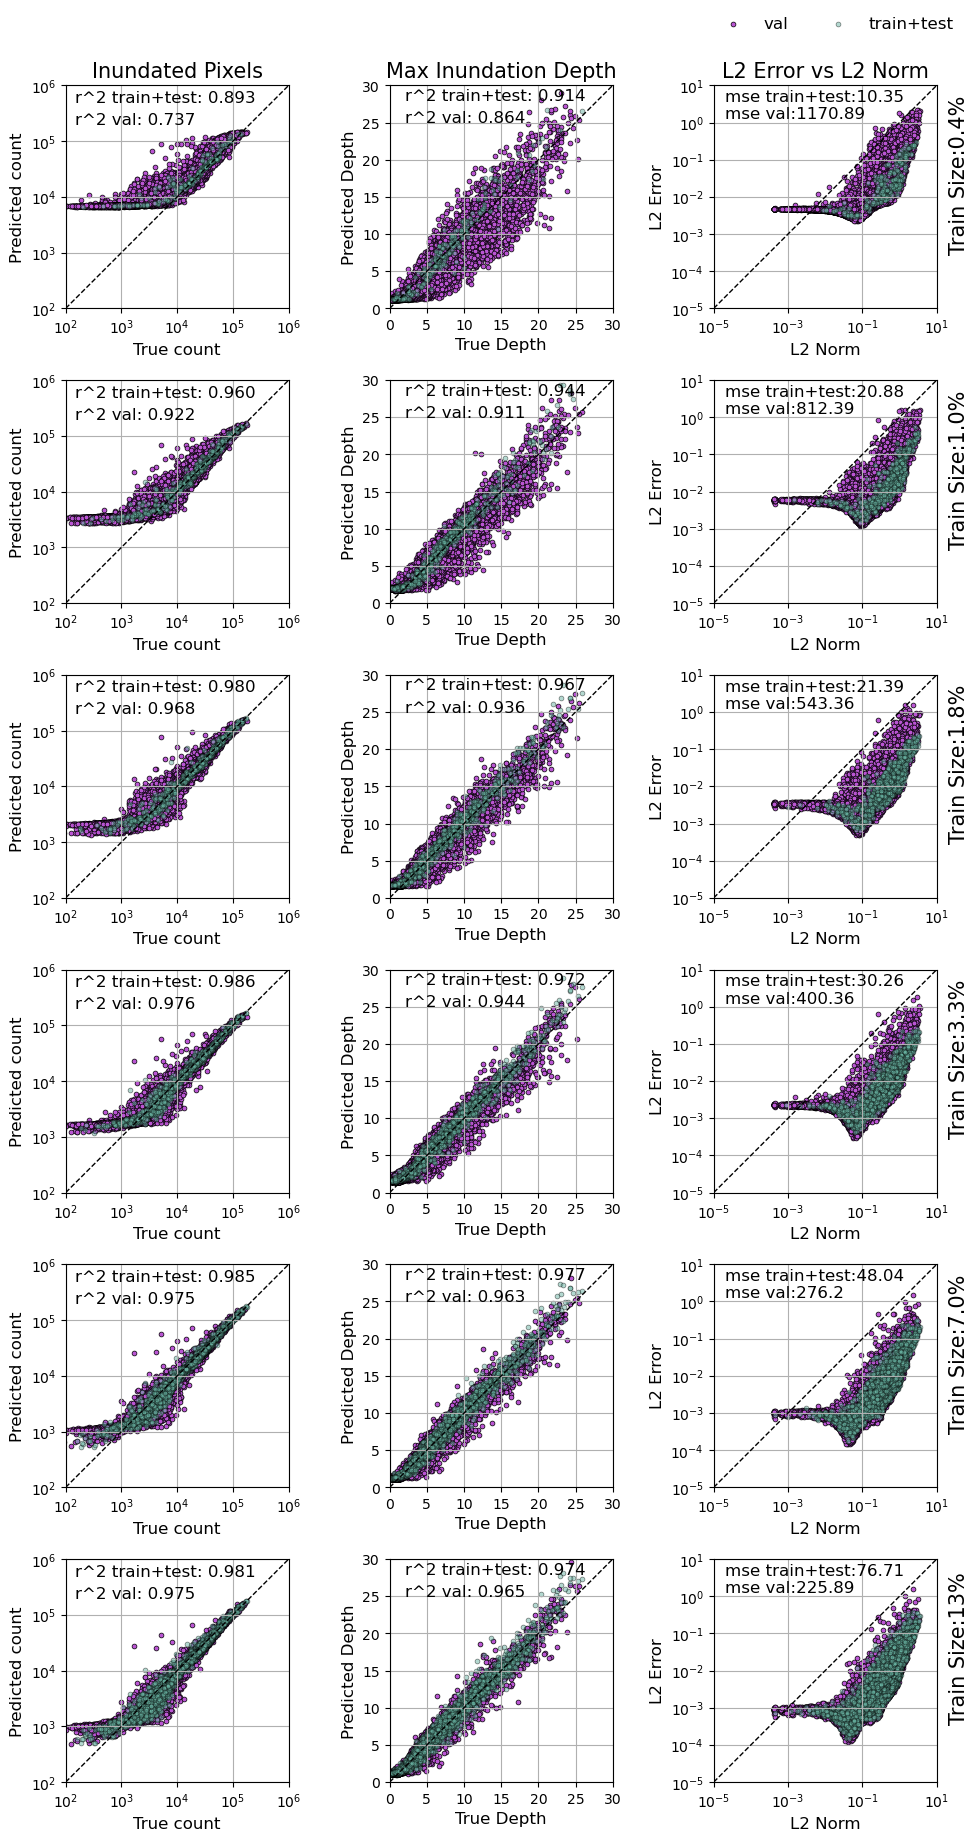

In [4]:
from sklearn.metrics import r2_score
from scipy.stats import gaussian_kde 
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from sklearn.metrics import r2_score
import xarray as xr

#select particular representative gauge
reg = 'SR'

if reg == 'CT':
    columnname = str(38)
    list_size = ['225', '529','892','1658','3454','7071']  
elif reg == 'SR':
    columnname = str(54)
    list_size = ['228', '550' ,'961','1773','3669','6941']

MLDir = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami' 
SimDir = "/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/simu/"
mask_size = list_size[2]

labels = ['0.4%', '1.0%', '1.8%', '3.3%', '7.0%', '13%']  # Example labels for training sizes


# Create a single figure with three axes
fig, ax = plt.subplots(6, 3, figsize=(10, 18))
for t,train_size in enumerate(list_size):
    eve_perf = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_compile_combined.csv')

    # Plot scatter of flood count
    x = eve_perf[eve_perf['split'] == 'test']['true']
    y = eve_perf[eve_perf['split'] == 'test']['pred']
    r2area = r2_score(x, y)
    scatter = ax[t,0].scatter(x, y, s=12,label='val', c='mediumorchid',edgecolors="k",linewidths=0.5,alpha = 1)
    #add r2 score at bottom right of axis
    ax[t,0].text(150,2e5,f"r^2 val: {r2area:.3f} ", fontsize=12)

    x = eve_perf[eve_perf['split'] == 'train']['true']
    y = eve_perf[eve_perf['split'] == 'train']['pred']
    r2area = r2_score(x, y)
    scatter = ax[t,0].scatter(x, y, s=12,label='train+test', c='#69b3a2',edgecolors="k",linewidths=0.5,alpha=0.5)
    ax[t,0].text(150,5e5,f"r^2 train+test: {r2area:.3f} ", fontsize=12)
    
    if t == 0:
        ax[t,0].set_title("Inundated Pixels",fontsize=15)
    
    ax[t,0].plot([0, 1], [0, 1], transform=ax[t,0].transAxes, color='k',linestyle = 'dashed',linewidth = 1)
    ax[t,0].set_aspect('equal', adjustable='box')
    ax[t,0].set_xscale('log')
    ax[t,0].set_yscale('log')
    ax[t,0].set_xlim(100, 1000000)
    ax[t,0].set_ylim(100, 1000000)
    ax[t,0].grid()
    ax[t,0].minorticks_off()
    ax[t,0].set_xlabel('True count',fontsize=12)
    ax[t,0].set_ylabel('Predicted count',fontsize=12)

    # Plot scatter of max depth for each event
    # Calculate the point density
   
    # Plot scatter of max depth for each event
    x = eve_perf[eve_perf['split'] == 'test']['truemax']
    y = eve_perf[eve_perf['split'] == 'test']['predmax']
    scatter = ax[t,1].scatter(x, y,s=12,label='val', c='mediumorchid',edgecolors="k",linewidths=0.5,alpha = 1)
    r2maxdepth = r2_score(x, y)
    ax[t,1].text(2, 25, f"r^2 val: {r2maxdepth:.3f} ", fontsize=12)

    x = eve_perf[eve_perf['split'] == 'train']['truemax']
    y = eve_perf[eve_perf['split'] == 'train']['predmax']
    scatter = ax[t,1].scatter(x, y,s=12,label='train+test', c='#69b3a2',edgecolors="k",linewidths=0.5,alpha=0.5)
    
    r2maxdepth = r2_score(x, y)
    ax[t,1].text(2, 28, f"r^2 train+test: {r2maxdepth:.3f} ", fontsize=12)

    ax[t,1].plot([0, 1], [0, 1], transform=ax[t,1].transAxes, color='k',linestyle = 'dashed',linewidth = 1)
    if t ==0:
        ax[t,1].set_title("Max Inundation Depth",fontsize=15)
    ax[t,1].set_xlim(0, 30)
    ax[t,1].set_ylim(0, 30)
    ax[t,1].grid()
    ax[t,1].set_xlabel('True Depth',fontsize=12)
    ax[t,1].set_ylabel('Predicted Depth',fontsize=12)
    ax[t,1].set_aspect('equal', adjustable='box')
    ax[t,1].xaxis.set_ticks(np.arange(0, 35, 5))

    # Plot scatter of mse vs l2norm
    x = eve_perf[eve_perf['split'] == 'test']['l2n']
    y = eve_perf[eve_perf['split'] == 'test']['mse']
    para_test = np.sum(y).round(2)
    scatter = ax[t,2].scatter(x, y, s=12,label='val', c='mediumorchid',edgecolors="k",linewidths=0.5,alpha = 1)

    x = eve_perf[eve_perf['split'] == 'train']['l2n']
    y = eve_perf[eve_perf['split'] == 'train']['mse']
    para_train = np.sum(y).round(2)
    scatter = ax[t,2].scatter(x, y,s=12,label='train+test', c='#69b3a2',edgecolors="k",linewidths=0.5,alpha=0.5)
    ax[t,2].text(0.05, 0.85, f"mse train+test:{para_train}\nmse val:{para_test}", fontsize=12,transform=ax[t,2].transAxes)
    
    ax[t,2].plot([0, 1], [0, 1], transform=ax[t,2].transAxes, color='k',linestyle = 'dashed',linewidth = 1)
    if t == 0:
        ax[t,2].set_title(f"L2 Error vs L2 Norm",fontsize=15)
    ax[t,2].set_aspect('equal', adjustable='box')
    ax[t,2].set_xscale('log')
    ax[t,2].set_yscale('log')
    ax[t,2].set_xlim(.00001, 10)
    ax[t,2].set_ylim(.00001, 10)
    ax[t,2].grid()
    ax[t,2].minorticks_off()
    ax[t,2].set_xlabel('L2 Norm',fontsize=12)
    ax[t,2].set_ylabel('L2 Error',fontsize=12)
    ax[t,2].text(1.1,0.6,f'Train Size:{labels[t]}',horizontalalignment='center',verticalalignment='center',transform=ax[t,2].transAxes,fontsize=15,rotation=90)


#save the plot
handles, labels = ax[t,2].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside upper right', fontsize=12, ncol=2,bbox_to_anchor=(.98, 1.025),frameon= False)
plt.tight_layout()
plt.savefig(f'./combined_trainingsize_{reg}.png',dpi=300, bbox_inches='tight')


Compare the training loss for different trainingn sizes and coupling pretrained components

/tmp/ipykernel_1591327/217276073.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('ocean', N)


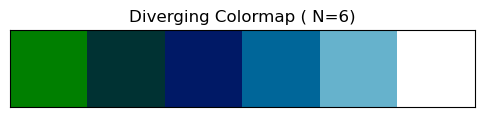

In [43]:
from matplotlib.colors import ListedColormap
cmap = cm.get_cmap('ocean', N)
colors = [cmap(i) for i in range(N)]
plt.figure(figsize=(6, 1))
plt.imshow([colors], aspect='auto')
plt.xticks([])
plt.yticks([])
plt.title("Diverging Colormap ( N=6)")
plt.show()


/tmp/ipykernel_851304/1652320640.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', N)


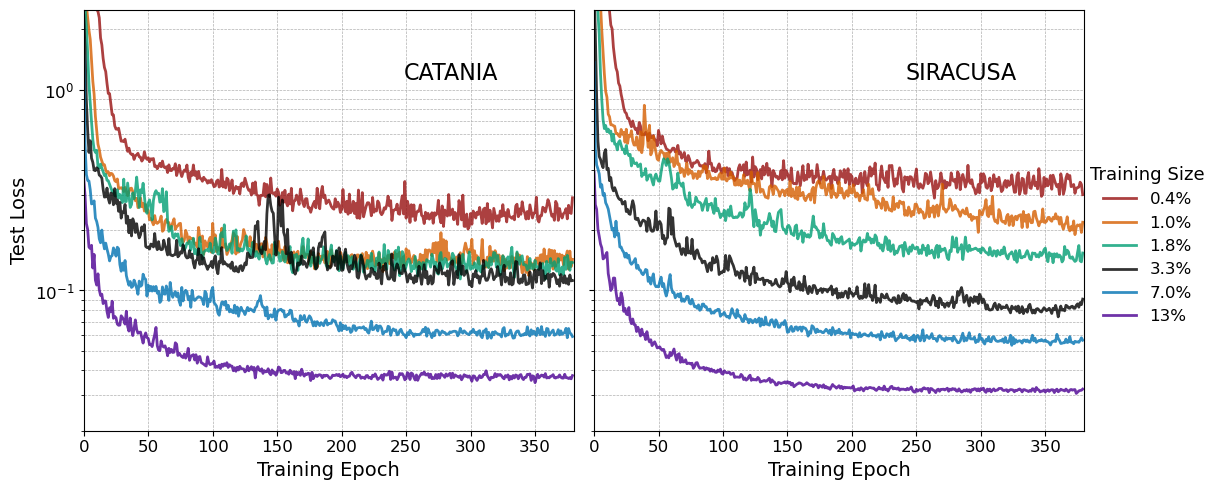

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

MLDir = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami' 
SimDir = "/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/simu/"

# Define colormap
N = 6  # number of training sizes
cmap = cm.get_cmap('tab10', N)
colors = [cmap(i) for i in range(N)]

colors = [
    "#971010", 
    "#d55e00", 
    "#009e73", 
    "#000000",  
    "#0072b2",
    "#4b0092",  
    "#e69f00"   
    ]

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Define datasets and sizes
regions = {
    'CT': ['225', '529', '892', '1658', '3454', '7071'],
    'SR': ['228', '550', '961', '1773', '3669', '6941']
}

labels = ['0.4%', '1.0%', '1.8%', '3.3%', '7.0%', '13%']  # Example labels for training sizes

for i, (reg, list_size) in enumerate(regions.items()):
    ax = axs[i]
    for t, train_size in enumerate(list_size):
        all_train_loss = np.zeros((4, 380))  # Initialize an array to hold losses for all folds
        for fold_no in range(4):
            train_loss_ = np.load(f"{MLDir}/model/{reg}/multifoldMC/out/test_loss_withdeform_{train_size}_fold_{fold_no}.npy")
            all_train_loss[fold_no, :] = train_loss_[0:380]
       
        train_loss_ = np.mean(all_train_loss, axis=0)  # Average over folds

        # Plot with reduced marker frequency
        ax.plot(train_loss_, label=f'{labels[t]}' if fold_no == 0 else "", 
                color=colors[t], linestyle='-', linewidth=2.0, #marker='o',
                    markersize=2.5, markevery=10, alpha=0.8)

    # Add region title
    ax.text(0.75, 0.85, 'CATANIA' if reg == 'CT' else 'SIRACUSA',
            horizontalalignment='center', verticalalignment='center',
            transform=ax.transAxes, fontsize=16)

   
    # Axis labels
    ax.set_xlabel('Training Epoch', fontsize=14)
    if i == 0:
        ax.set_ylabel('Test Loss', fontsize=14)
    
    # Aesthetic settings
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.set_xlim(0, 380)
    ax.set_ylim(0.02, 2.5)
    ax.set_yscale('log')

fig.legend(labels, title="Training Size", fontsize=12, title_fontsize=13,
           loc='center left', bbox_to_anchor=(0.9, 0.5), frameon=False)

plt.tight_layout(rect=[0, 0, 0.92, 1])  # adjust right space for legend
plt.savefig('./testloss_SR_CT_epoch_meanoffolds.png', dpi=300, bbox_inches='tight')
plt.show()


/mnt/beegfs/nragu/tsunami/env/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/mnt/beegfs/nragu/tsunami/env/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


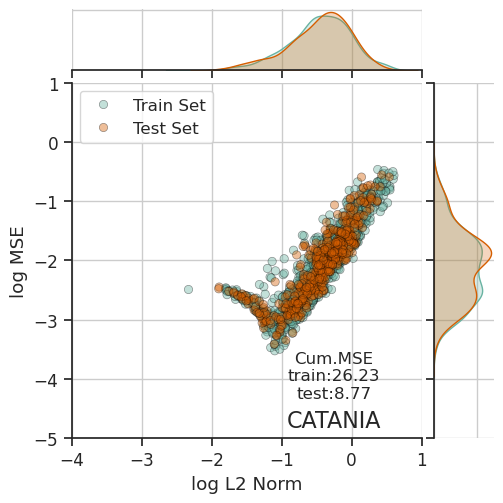

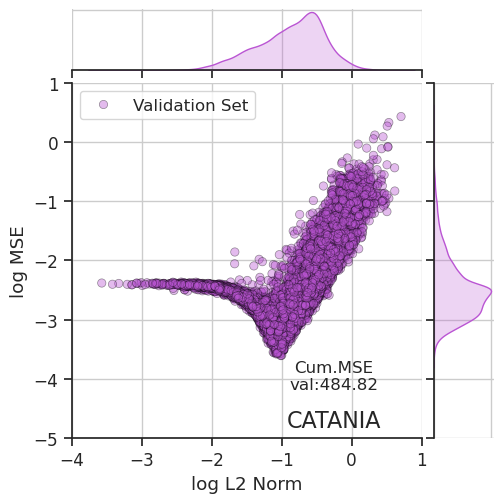

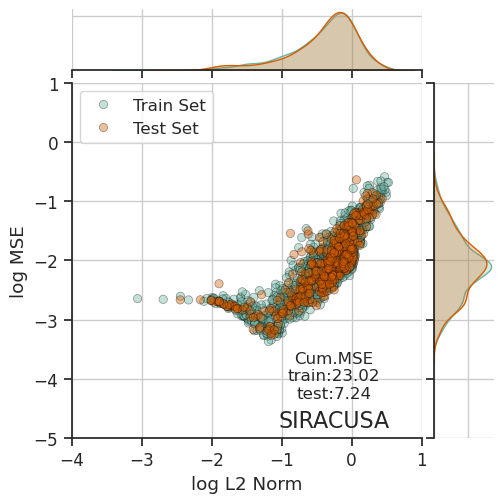

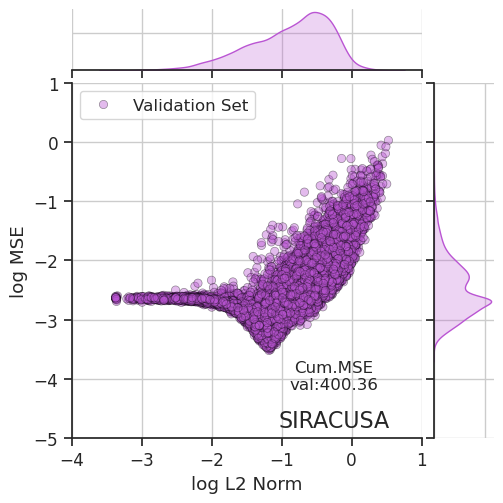

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

MLDir = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami' 
SimDir = "/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/simu/"

for r,reg in enumerate(['CT','SR']):#
    if reg == 'CT':
        columnname = str(38)
        list_size = ['225', '529', '892', '1658', '3454', '7071'] 
    elif reg == 'SR':
        columnname = str(54)
        list_size = ['228', '550', '961', '1773', '3669', '6941']
    mask_size = list_size[2]
    for s in range(3, 4):
        train_size = list_size[s]

        eve_perf = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_compile_combined.csv')

        train_set = np.loadtxt(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/events/shuffled_events_{reg}_{train_size}.txt',dtype='str') 
        #shuffle the train set
        # np.random.shuffle(train_set)
        test_set = train_set[int(0.75*len(train_set)):]
        train_set = train_set[:int(0.75*len(train_set))]
        test_len = len(eve_perf[eve_perf['split'] == 'test'])
        val_len = len(eve_perf[eve_perf['id'].isin(test_set)])

        #Plot scatter of mse vs l2norm for 75% and 25% of train set
        x1 = eve_perf[eve_perf['id'].isin(train_set)]['l2n']
        y1 = eve_perf[eve_perf['id'].isin(train_set)]['mse']
        xy1 = pd.DataFrame({'L2 Norm':x1,'MSE':y1,'Data':'Train Set'})
        para_train = np.sum(y1).round(2)

        x2 = eve_perf[eve_perf['id'].isin(test_set)]['l2n'].to_numpy()
        y2 = eve_perf[eve_perf['id'].isin(test_set)]['mse'].to_numpy()
        xy2 = pd.DataFrame({'L2 Norm':x2,'MSE':y2,'Data':'Test Set'})
        para_test = np.sum(y2).round(2)
        
        df = pd.concat([xy1,xy2]) 
        #calculate log of values
        df['log L2 Norm'] = np.log10(df['L2 Norm'])
        df['log MSE'] = np.log10(df['MSE'])

        sns.set_style("ticks",{'axes.grid' : True})   
        #set font size as 12
        sns.set_context("notebook", font_scale=1.1, rc={"lines.linewidth": 1})
        g = sns.JointGrid(xlim=(-4,1), ylim=(-5,1),height=5)
        
        sns.scatterplot(data = df,x='log L2 Norm',y='log MSE',hue='Data', ax=g.ax_joint,palette=['#69b3a2', "#d55e00"],
                    alpha=.4,edgecolor='k',linewidth=0.5,hue_order=['Train Set','Test Set'])
        sns.kdeplot(y=df[df['Data']=='Train Set']['log MSE'], linewidth=1, ax=g.ax_marg_y, color='#69b3a2',fill=True)
        sns.kdeplot(x=df[df['Data']=='Train Set']['log L2 Norm'], linewidth=1, ax=g.ax_marg_x, color='#69b3a2',fill=True)
        sns.kdeplot(y=df[df['Data']=='Test Set']['log MSE'], linewidth=1, ax=g.ax_marg_y, color= "#d55e00",fill=True)
        sns.kdeplot(x=df[df['Data']=='Test Set']['log L2 Norm'], linewidth=1, ax=g.ax_marg_x, color= "#d55e00",fill=True)

        g.ax_marg_y.grid(True)
        g.ax_marg_x.grid(True)

        #set legend at top left
        handles, labels = g.ax_joint.get_legend_handles_labels()
        g.ax_joint.legend(handles, labels, loc='upper left', fontsize=12, frameon=True)

    
        plt.text(0.75, 0.175, f'Cum.MSE\ntrain:{para_train}\ntest:{para_test}', horizontalalignment='center', verticalalignment='center', transform=g.ax_joint.transAxes, fontsize=12)  # Adding text to the graph
        if reg == 'CT':
            plt.text(0.75, 0.05, 'CATANIA', horizontalalignment='center', verticalalignment='center', transform=g.ax_joint.transAxes, fontsize=16)  
        elif reg == 'SR':
            plt.text(0.75, 0.05, 'SIRACUSA', horizontalalignment='center', verticalalignment='center',transform=g.ax_joint.transAxes, fontsize=16) 
        plt.savefig(f'./l2normerror_jointplot_{train_size}_{reg}_train_test.png',dpi=150, bbox_inches='tight')

        #Plot scatter of mse vs l2norm for test set

        #Pretrain
        x2 = eve_perf[eve_perf['split'] == 'test']['l2n']
        y2 = eve_perf[eve_perf['split'] == 'test']['mse']
        xy2 = pd.DataFrame({'L2 Norm':x2,'MSE':y2,'Data':'Validation Set'})
        para = np.sum(y2).round(2)
        df = xy2  
        #calculate log of values
        df['log L2 Norm'] = np.log10(df['L2 Norm'])
        df['log MSE'] = np.log10(df['MSE'])

        #shuffle the data
        df = df.sample(frac=0.5).reset_index(drop=True)
        sns.set_style("ticks",{'axes.grid' : True})   
        #set font size as 12
        sns.set_context("notebook", font_scale=1.1, rc={"lines.linewidth": 1})
        g = sns.JointGrid(xlim=(-4,1), ylim=(-5,1),height=5)
        sns.scatterplot(data = df,x='log L2 Norm',y='log MSE',hue='Data', ax=g.ax_joint,palette=['mediumorchid'],
                    alpha=.4,edgecolor='k',linewidth=0.5,hue_order=['Validation Set'])
        sns.kdeplot(y=df[df['Data']=='Validation Set']['log MSE'], linewidth=1, ax=g.ax_marg_y, color='mediumorchid',fill=True)
        sns.kdeplot(x=df[df['Data']=='Validation Set']['log L2 Norm'], linewidth=1, ax=g.ax_marg_x, color='mediumorchid',fill=True)
        g.ax_marg_y.grid(True)
        g.ax_marg_x.grid(True)

        #set legend at top left
        handles, labels = g.ax_joint.get_legend_handles_labels()
        g.ax_joint.legend(handles, labels, loc='upper left', fontsize=12, frameon=True)

    
        plt.text(0.75, 0.175, f'Cum.MSE\nval:{para}', horizontalalignment='center', verticalalignment='center', transform=g.ax_joint.transAxes, fontsize=12)  # Adding text to the graph
        if reg == 'CT':
            plt.text(0.75, 0.05, 'CATANIA', horizontalalignment='center', verticalalignment='center', transform=g.ax_joint.transAxes, fontsize=16)  
        elif reg == 'SR':
            plt.text(0.75, 0.05, 'SIRACUSA', horizontalalignment='center', verticalalignment='center',transform=g.ax_joint.transAxes, fontsize=16) 
        plt.savefig(f'./l2normerror_jointplot_{train_size}_{reg}_val.png',dpi=150, bbox_inches='tight')


/mnt/beegfs/nragu/tsunami/env/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/mnt/beegfs/nragu/tsunami/env/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/mnt/beegfs/nragu/tsunami/env/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/mnt/beegfs/nragu/tsunami/env/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/mnt/beegfs/nragu/tsunami/env/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/mnt/beegfs/nragu/tsunami/env/

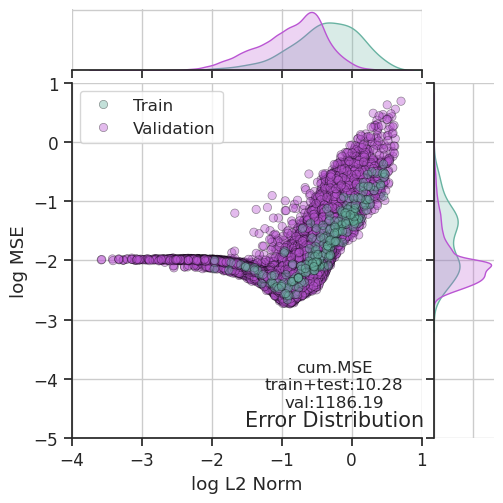

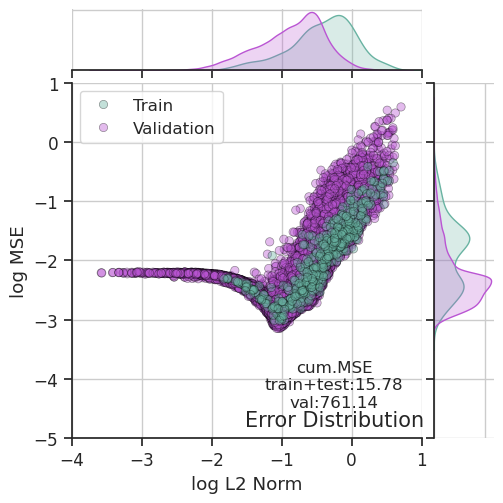

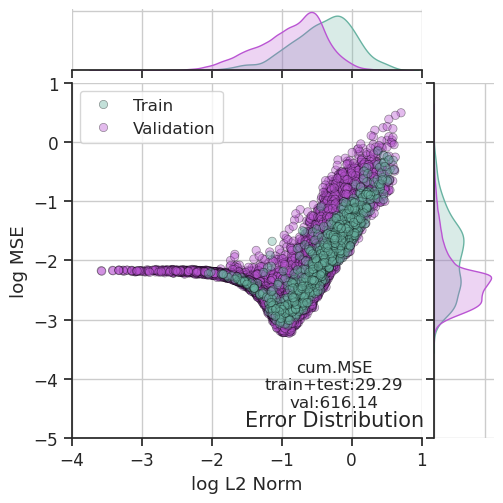

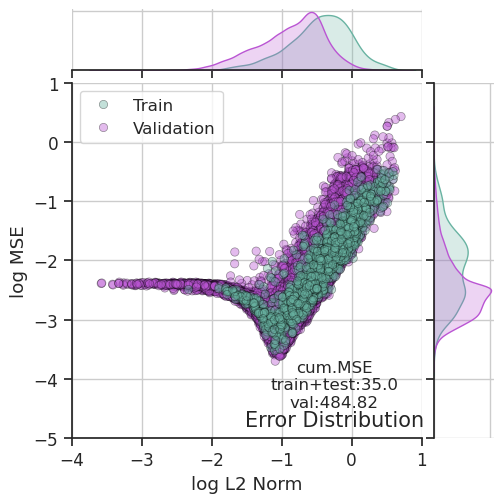

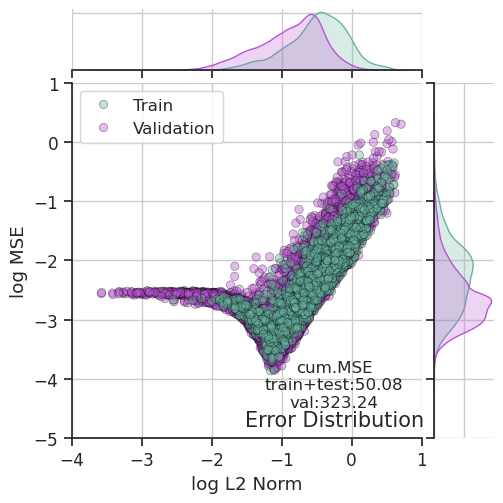

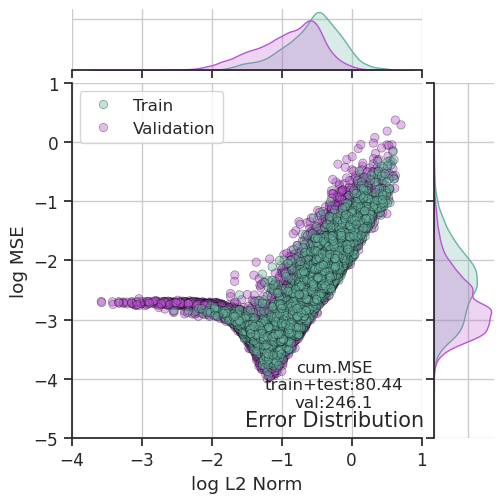

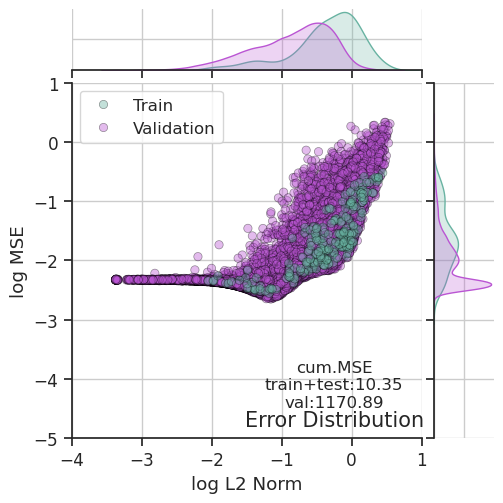

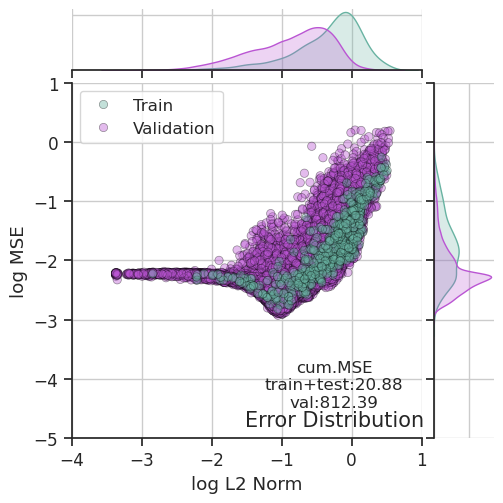

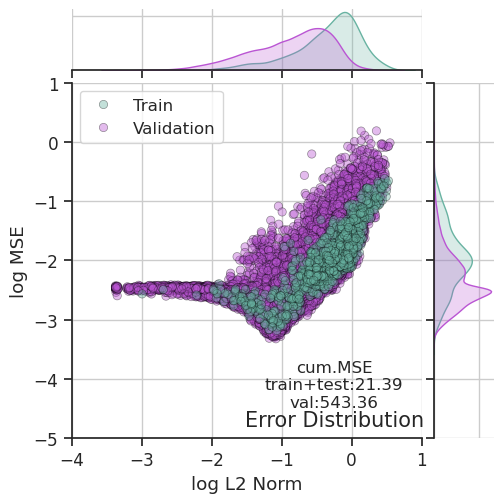

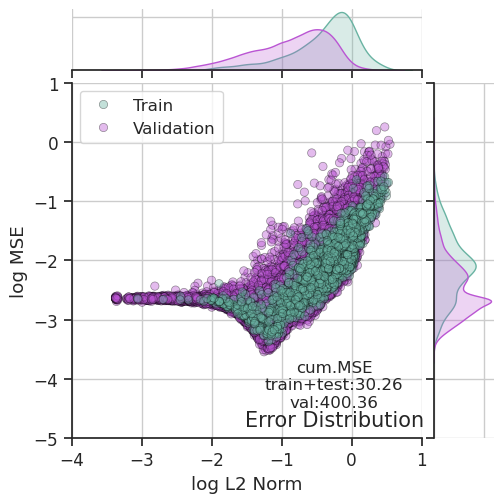

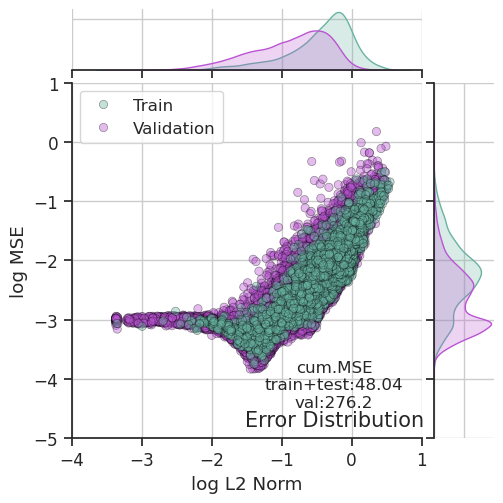

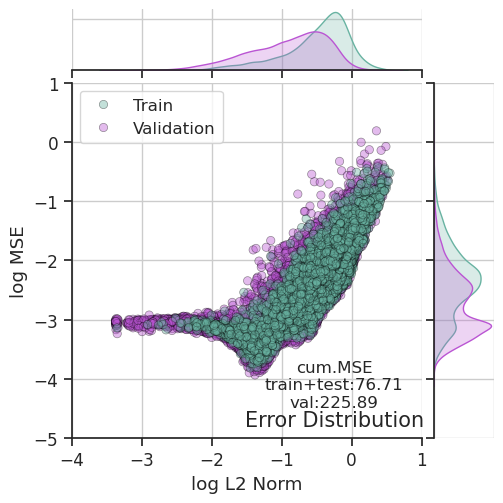

In [21]:
from sklearn.metrics import r2_score
from scipy.stats import gaussian_kde 
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from sklearn.metrics import r2_score
import xarray as xr
import seaborn as sns

#select particular representative gauge

for r,reg in enumerate(['CT','SR']):#
    if reg == 'CT':
        columnname = str(38)
        list_size = ['225', '529', '892', '1658', '3454', '7071'] 
    elif reg == 'SR':
        columnname = str(54)
        list_size = ['228', '550', '961', '1773', '3669', '6941']
    mask_size = list_size[2]


    for t,train_size in enumerate(list_size):
        eve_perf = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_compile_combined.csv')

        #change test to validation
        eve_perf['split'] = eve_perf['split'].replace({'test': 'validation'})

        # Plot scatter of mse vs l2norm
        x1 = eve_perf[eve_perf['split'] == 'validation']['l2n']
        y1 = eve_perf[eve_perf['split'] == 'validation']['mse']
        xy1 = pd.DataFrame({'L2 Norm':x1,'MSE':y1,'Events':'Validation'})
        para_test = np.sum(y1).round(2)
        x2 = eve_perf[eve_perf['split'] == 'train']['l2n']
        y2 = eve_perf[eve_perf['split'] == 'train']['mse']
        xy2 = pd.DataFrame({'L2 Norm':x2,'MSE':y2,'Events':'Train'})
        para_train = np.sum(y2).round(2)
        df = pd.concat([xy1,xy2]) 
        #calculate log of values
        df['log L2 Norm'] = np.log10(df['L2 Norm'])
        df['log MSE'] = np.log10(df['MSE'])


        sns.set_style("ticks",{'axes.grid' : True})   
        #set font size as 12
        sns.set_context("notebook", font_scale=1.1, rc={"lines.linewidth": 1})
        g = sns.JointGrid(xlim=(-4,1), ylim=(-5,1),height=5)
        sns.scatterplot(data = df,x='log L2 Norm',y='log MSE',hue='Events', ax=g.ax_joint,palette=['#69b3a2','mediumorchid'],
                    alpha=.4,edgecolor='k',linewidth=0.5,hue_order=['Train','Validation'])
        sns.kdeplot(y=df[df['Events']=='Train']['log MSE'], linewidth=1, ax=g.ax_marg_y, color='#69b3a2',fill=True)
        sns.kdeplot(y=df[df['Events']=='Validation']['log MSE'], linewidth=1, ax=g.ax_marg_y, color='mediumorchid',fill=True)
        sns.kdeplot(x=df[df['Events']=='Train']['log L2 Norm'], linewidth=1, ax=g.ax_marg_x, color='#69b3a2',fill=True)
        sns.kdeplot(x=df[df['Events']=='Validation']['log L2 Norm'], linewidth=1, ax=g.ax_marg_x, color='mediumorchid',fill=True)
    
        g.ax_marg_y.grid(True)
        g.ax_marg_x.grid(True)

        #set legend at top left
        handles, labels = g.ax_joint.get_legend_handles_labels()
        g.ax_joint.legend(handles, labels, loc='upper left', fontsize=12, frameon=True)

        plt.text(0.75,0.15,f"cum.MSE\ntrain+test:{para_train}\nval:{para_test}", horizontalalignment='center', verticalalignment='center', transform=g.ax_joint.transAxes, fontsize=12)  # Adding text to the graph
        plt.text(0.75,0.05,"Error Distribution",fontsize=15,horizontalalignment='center', verticalalignment='center', transform=g.ax_joint.transAxes)
        plt.xlabel('log L2 Norm',fontsize=12)
        plt.ylabel('log MSE',fontsize=12)
        plt.savefig(f'./size_error_{train_size}_{reg}_trainval.png', dpi=300, bbox_inches='tight')


Misfit plot

[573785, 561728, 530792, 507751, 507274, 481772, 400027, 318807, 229769, 155881, 82539, 303797]


/tmp/ipykernel_2223376/1576450994.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


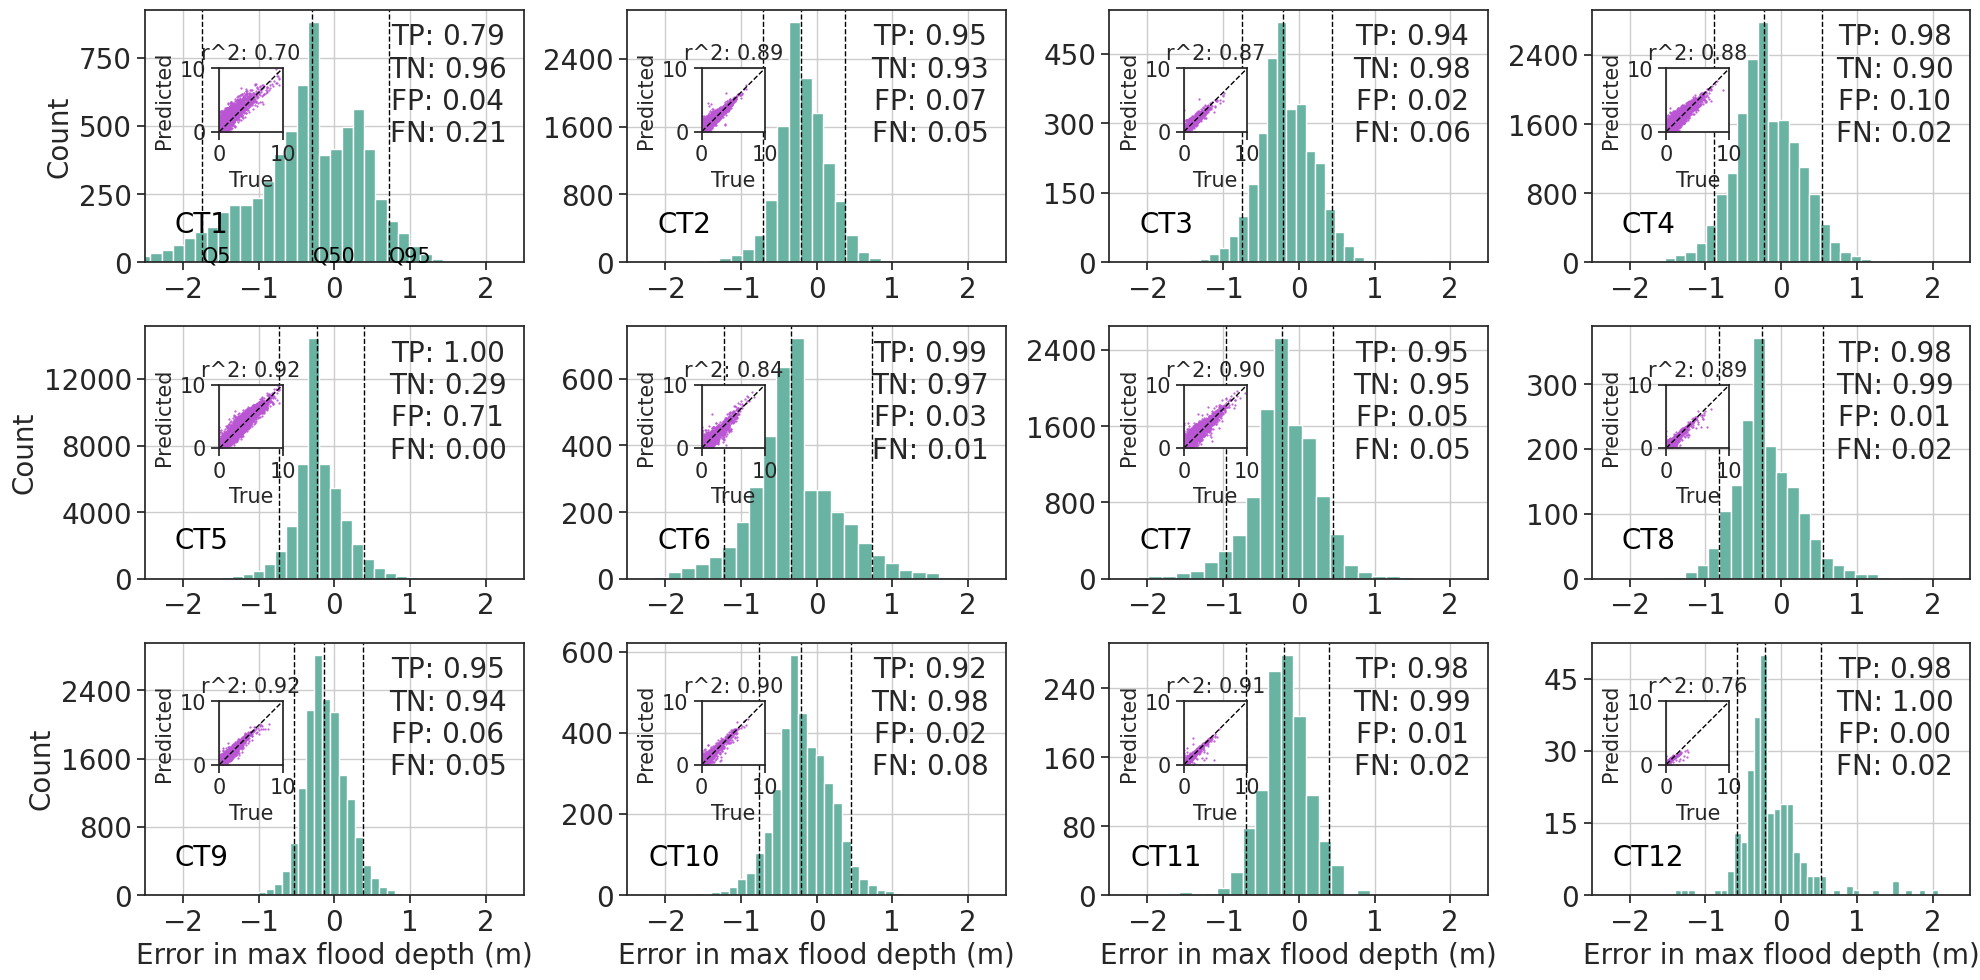

In [7]:
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import xarray as xr
import matplotlib.pyplot as plt
import contextily as cx
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Load file
MLDir = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami' 
SimDir = "/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/simu/"
reg = 'CT'

if reg == 'CT':
    columnname = str(38)
    list_size = ['225', '529', '892', '1658', '3454', '7071'] 
    control_points =  [[37.5022,15.0960],
            [37.48876,15.08936],
            [37.47193,15.07816],
            [37.46273,15.08527],
            [37.46252,15.08587],
            [37.45312,15.07874],
            [37.42821,15.08506],
            [37.40958,15.08075],
            [37.38595,15.08539],
            [37.35084,15.08575],
            [37.33049,15.07029],
            [37.40675,15.05037]]
elif reg == 'SR':
    columnname = str(54)
    list_size = ['228', '550', '961', '1773', '3669', '6941']
    control_points = [[37.01,15.29],
            [37.06757,15.28709],
            [37.05266,15.26536],
            [37.03211,15.28632]]

mask_size = list_size[2]
train_size = list_size[3]

def get_idx_from_latlon(locations,reg,MLDir,SimDir,mask_size):  
    #get first event to get lat lon
    firstevent = np.loadtxt(f'{MLDir}/data/events/sample_events53550.txt',dtype='str')[0]
    D_grids = xr.open_dataset(f'{SimDir}/{firstevent}/{reg}_flowdepth.nc')
    zero_mask = np.load(f'{MLDir}/data/processed/zero_mask_{reg}_{mask_size}.npy')
    non_zero_list = np.argwhere(~zero_mask).tolist()

    #iterate over list locations
    indices = []
    for loc in locations: 
        #get index of lat lon
        lat_idx = np.argmin(np.abs(D_grids.lat.values - loc[0]))
        lon_idx = np.argmin(np.abs(D_grids.lon.values - loc[1]))

        #get idx in non zero mask list from lat_idx and lon_idx
        idx = non_zero_list.index([lat_idx,lon_idx])
        indices.append(idx)

    # return lat_idx, lon_idx, idx
    print(indices)
    return indices

threshold = 0.2

#keep every second element from the list
# control_points = control_points[::1]
locindices = get_idx_from_latlon(control_points,reg,MLDir,SimDir,mask_size)

true_pred_er = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_true_pred_er_combined.csv')
test = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_compile_combined.csv', sep=",")['split']
test = test == 'test'
#keep every second column from the dataframe
# true_pred_er = true_pred_er.iloc[:,::2]
#filter all columns with column name starting with E of true_pred_er
er_list = true_pred_er.iloc[:,true_pred_er.columns.str.startswith('E')].values 
#remove first and last column 
true_pred_er = true_pred_er.iloc[:,1:-1].values
true_pred_er = true_pred_er[test]
fig, axes = plt.subplots(3, 4, figsize=(20, 10), sharex=False)
common_xlim = (-2.5, 2.5)
common_inset_xlim = (0, 10)
common_inset_ylim = (0, 10)
font_size_main = 20
font_size_inset = 15
num_bins = 40

for i, ax in enumerate(axes.flatten()):
    if i >= len(locindices):
        ax.axis('off')
        continue

    errors = er_list[er_list[:, i] != 0, i]
    
    ax.hist(errors, bins=num_bins, edgecolor='white',color='#69b3a2',alpha=1)
    ax.set_xlim(common_xlim)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))  
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5)) 
    ax.xaxis.set_tick_params(labelsize=font_size_main)
    ax.yaxis.set_tick_params(labelsize=font_size_main)
    marks=[5, 50, 95]
    if len(errors) != 0:
        quantiles = np.percentile(errors, marks)
        for q in quantiles:
            ax.axvline(q, color='k', linestyle='--', label=f'Q{int(q)}')
            #mark label on top of axis
    if i==0:
        for j in [0,1,2]:
            ax.text(quantiles[j], 1, f"Q{str(marks[j])}", 
                    fontsize=font_size_inset, color='k')
    
    neve = np.count_nonzero(true_pred_er[:, i] > threshold)
    neve_recon = np.count_nonzero(true_pred_er[:, i + len(locindices)] > threshold)
    
    if neve == 0:
        TP = FN = -999
    else:
        TP = np.count_nonzero((true_pred_er[:, i] > threshold) & 
                              (true_pred_er[:, i + len(locindices)] > threshold)) / neve
        FN = np.count_nonzero((true_pred_er[:, i] > threshold) & 
                              (true_pred_er[:, i + len(locindices)] <= threshold)) / neve
    
    TN = np.count_nonzero((true_pred_er[:, i] <= threshold) & 
                          (true_pred_er[:, i + len(locindices)] <= threshold)) / (len(true_pred_er[:, i]) - neve)
    FP = np.count_nonzero((true_pred_er[:, i] <= threshold) & 
                          (true_pred_er[:, i + len(locindices)] > threshold)) / (len(true_pred_er[:, i]) - neve)
    
    ax.text(0.15, 0.15, f"CT{i+1}", horizontalalignment='center', 
            verticalalignment='center', transform=ax.transAxes, 
            fontsize=font_size_main, color='k')
    ax.text(0.8, 0.7, f"TP: {TP:.2f}\nTN: {TN:.2f}\nFP: {FP:.2f}\nFN: {FN:.2f}", 
            horizontalalignment='center', verticalalignment='center', 
            transform=ax.transAxes, fontsize=font_size_main)

    if i > 7:
        ax.set_xlabel('Error in max flood depth (m)', fontsize=font_size_main)
    if i in [0,4,8,12]:
        ax.set_ylabel('Count', fontsize=font_size_main)
    
    # Inset scatter plot
    axins = inset_axes(ax, width="25%", height="25%", loc='upper left', borderpad=3.5)
    axins.plot([0, 1], [0, 1], transform=axins.transAxes, color='k', linestyle='--')
    axins.scatter(true_pred_er[:, i], true_pred_er[:, i + len(locindices)], 
                  marker='o', color='mediumorchid', label='Max Inun Depth', s=0.33)
    axins.set_title(f'r^2: {r2_score(true_pred_er[:, i], true_pred_er[:, i + len(locindices)]):.2f}',fontsize=font_size_inset)
    axins.set_xlim(common_inset_xlim)
    axins.set_ylim(common_inset_ylim)
    axins.set_xticks([0, 10])
    axins.set_yticks([0, 10])
    axins.set_xlabel('True', fontsize=font_size_inset)
    axins.set_ylabel('Predicted', fontsize=font_size_inset)
    axins.set_aspect('equal', adjustable='box')
    axins.tick_params(axis='x', labelsize=font_size_inset)
    axins.tick_params(axis='y', labelsize=font_size_inset)

plt.tight_layout()
plt.savefig(f'./error_test_combined_{reg}_{train_size}.png', transparent=False) 

[29720, 202349, 153030, 94497]


/tmp/ipykernel_2223376/3688030205.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


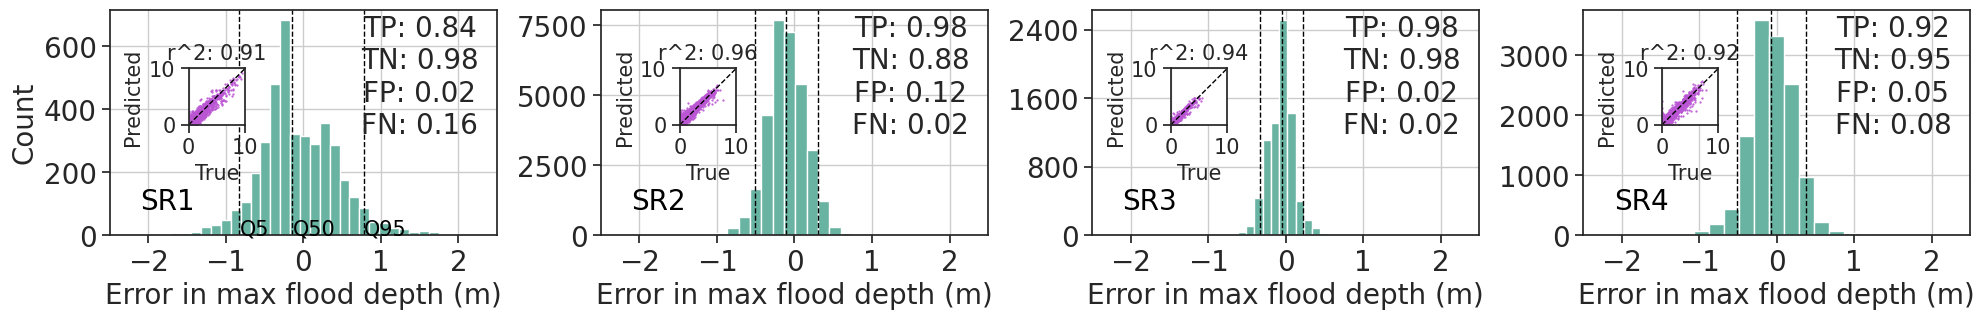

In [9]:
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import xarray as xr
import matplotlib.pyplot as plt
import contextily as cx
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Load file
MLDir = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami' 
SimDir = "/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/simu/"
reg = 'SR'

if reg == 'CT':
    columnname = str(38)
    list_size = ['225', '529', '892', '1658', '3454', '7071'] 
    control_points =  [[37.5022,15.0960],
            [37.48876,15.08936],
            [37.47193,15.07816],
            [37.46273,15.08527],
            [37.46252,15.08587],
            [37.45312,15.07874],
            [37.42821,15.08506],
            [37.40958,15.08075],
            [37.38595,15.08539],
            [37.35084,15.08575],
            [37.33049,15.07029],
            [37.40675,15.05037]]
elif reg == 'SR':
    columnname = str(54)
    list_size = ['228', '550', '961', '1773', '3669', '6941']
    control_points = [[37.01,15.29],
            [37.06757,15.28709],
            [37.05266,15.26536],
            [37.03211,15.28632]]

mask_size = list_size[2]
train_size = list_size[3]

def get_idx_from_latlon(locations,reg,MLDir,SimDir,mask_size):  
    #get first event to get lat lon
    firstevent = np.loadtxt(f'{MLDir}/data/events/sample_events53550.txt',dtype='str')[0]
    D_grids = xr.open_dataset(f'{SimDir}/{firstevent}/{reg}_flowdepth.nc')
    zero_mask = np.load(f'{MLDir}/data/processed/zero_mask_{reg}_{mask_size}.npy')
    non_zero_list = np.argwhere(~zero_mask).tolist()

    #iterate over list locations
    indices = []
    for loc in locations: 
        #get index of lat lon
        lat_idx = np.argmin(np.abs(D_grids.lat.values - loc[0]))
        lon_idx = np.argmin(np.abs(D_grids.lon.values - loc[1]))

        #get idx in non zero mask list from lat_idx and lon_idx
        idx = non_zero_list.index([lat_idx,lon_idx])
        indices.append(idx)

    # return lat_idx, lon_idx, idx
    print(indices)
    return indices

threshold = 0.2

#keep every second element from the list
# control_points = control_points[::1]
locindices = get_idx_from_latlon(control_points,reg,MLDir,SimDir,mask_size)

true_pred_er = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_true_pred_er_combined.csv')
test = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_compile_combined.csv', sep=",")['split']
test = test == 'test'
#keep every second column from the dataframe
# true_pred_er = true_pred_er.iloc[:,::2]
#filter all columns with column name starting with E of true_pred_er
er_list = true_pred_er.iloc[:,true_pred_er.columns.str.startswith('E')].values 
#remove first and last column 
true_pred_er = true_pred_er.iloc[:,1:-1].values
true_pred_er = true_pred_er[test]

fig, axes = plt.subplots(1, 4, figsize=(20, 3.4), sharex=False)
common_xlim = (-2.5, 2.5)
common_inset_xlim = (0, 10)
common_inset_ylim = (0, 10)
font_size_main = 20
font_size_inset = 15
num_bins = 40

for i, ax in enumerate(axes.flatten()):
    if i >= len(locindices):
        ax.axis('off')
        continue

    errors = er_list[er_list[:, i] != 0, i]
    
    ax.hist(errors, bins=num_bins, edgecolor='white',color='#69b3a2',alpha=1)
    ax.set_xlim(common_xlim)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))  
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5)) 
    ax.xaxis.set_tick_params(labelsize=font_size_main)
    ax.yaxis.set_tick_params(labelsize=font_size_main)
    marks=[5, 50, 95]
    if len(errors) != 0:
        quantiles = np.percentile(errors, marks)
        for q in quantiles:
            ax.axvline(q, color='k', linestyle='--', label=f'Q{int(q)}')
            #mark label on top of axis
    if i==0:
        for j in [0,1,2]:
            ax.text(quantiles[j], 1, f"Q{str(marks[j])}", 
                    fontsize=font_size_inset, color='k')
    
    neve = np.count_nonzero(true_pred_er[:, i] > threshold)
    neve_recon = np.count_nonzero(true_pred_er[:, i + len(locindices)] > threshold)
    
    if neve == 0:
        TP = FN = -999
    else:
        TP = np.count_nonzero((true_pred_er[:, i] > threshold) & 
                              (true_pred_er[:, i + len(locindices)] > threshold)) / neve
        FN = np.count_nonzero((true_pred_er[:, i] > threshold) & 
                              (true_pred_er[:, i + len(locindices)] <= threshold)) / neve
    
    TN = np.count_nonzero((true_pred_er[:, i] <= threshold) & 
                          (true_pred_er[:, i + len(locindices)] <= threshold)) / (len(true_pred_er[:, i]) - neve)
    FP = np.count_nonzero((true_pred_er[:, i] <= threshold) & 
                          (true_pred_er[:, i + len(locindices)] > threshold)) / (len(true_pred_er[:, i]) - neve)
    
    ax.text(0.15, 0.15, f"SR{i+1}", horizontalalignment='center', 
            verticalalignment='center', transform=ax.transAxes, 
            fontsize=font_size_main, color='k')
    ax.text(0.8, 0.7, f"TP: {TP:.2f}\nTN: {TN:.2f}\nFP: {FP:.2f}\nFN: {FN:.2f}", 
            horizontalalignment='center', verticalalignment='center', 
            transform=ax.transAxes, fontsize=font_size_main)

    if i >= 0:
        ax.set_xlabel('Error in max flood depth (m)', fontsize=font_size_main)
    if i in [0,4,8,12]:
        ax.set_ylabel('Count', fontsize=font_size_main)
    
    # Inset scatter plot
    axins = inset_axes(ax, width="25%", height="25%", loc='upper left', borderpad=3.5)
    axins.plot([0, 1], [0, 1], transform=axins.transAxes, color='k', linestyle='--')
    axins.scatter(true_pred_er[:, i], true_pred_er[:, i + len(locindices)], 
                  marker='o', color='mediumorchid', label='Max Inun Depth', s=0.33)
    # axins.text(0.5, 10.1, f'r^2: {r2_score(true_pred_er[:, i], true_pred_er[:, i + len(locindices)]):.2f}', 
    #            fontsize=font_size_inset)
    axins.set_title(f'r^2: {r2_score(true_pred_er[:, i], true_pred_er[:, i + len(locindices)]):.2f}',fontsize=font_size_inset)
    axins.set_xlim(common_inset_xlim)
    axins.set_ylim(common_inset_ylim)
    axins.set_xticks([0, 10])
    axins.set_yticks([0, 10])
    axins.set_xlabel('True', fontsize=font_size_inset)
    axins.set_ylabel('Predicted', fontsize=font_size_inset)
    axins.set_aspect('equal', adjustable='box')
    axins.tick_params(axis='x', labelsize=font_size_inset)
    axins.tick_params(axis='y', labelsize=font_size_inset)

plt.tight_layout()
plt.savefig(f'./error_test_combined_{reg}_{train_size}.png', transparent=False) 

Check model parameters and size

In [ ]:
import sys, os
os.chdir('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/scripts/JGR')
from torchsummary import summary
import torch
model = torch.load(f"/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/SR/multifoldMC/out/model_withdeform_off[64, 128, 256]_on[16, 128, 128]_minepoch_6941_fold_3.pt",map_location=torch.device('cpu'))
model.eval()
summary(model,[(5,480),(948,1300)]) #SR output ,(224124,1)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1              [-1, 64, 480]           1,024
         LeakyReLU-2              [-1, 64, 480]               0
         MaxPool1d-3              [-1, 64, 240]               0
            Conv1d-4             [-1, 128, 240]          24,704
         LeakyReLU-5             [-1, 128, 240]               0
         MaxPool1d-6             [-1, 128, 120]               0
            Conv1d-7             [-1, 256, 120]          98,560
         LeakyReLU-8             [-1, 256, 120]               0
         MaxPool1d-9              [-1, 256, 60]               0
          Dropout-10              [-1, 256, 60]               0
          Flatten-11                [-1, 15360]               0
           Linear-12                   [-1, 64]         983,104
           Conv2d-13         [-1, 16, 474, 650]             160
        LeakyReLU-14         [-1, 16, 4

In [5]:
import sys, os
os.chdir('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/scripts/JGR')
from torchsummary import summary
import torch
model = torch.load(f"/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/CT/multifoldMC/out/model_withdeform_off[64, 128, 256]_on[16, 128, 128]_minepoch_1658_fold_3.pt",map_location=torch.device('cpu'))
model.eval()
summary(model,[(9,480),(912,2224)]) #CT output(518665,1)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1              [-1, 64, 480]           1,792
         LeakyReLU-2              [-1, 64, 480]               0
         MaxPool1d-3              [-1, 64, 240]               0
            Conv1d-4             [-1, 128, 240]          24,704
         LeakyReLU-5             [-1, 128, 240]               0
         MaxPool1d-6             [-1, 128, 120]               0
            Conv1d-7             [-1, 256, 120]          98,560
         LeakyReLU-8             [-1, 256, 120]               0
         MaxPool1d-9              [-1, 256, 60]               0
          Dropout-10              [-1, 256, 60]               0
          Flatten-11                [-1, 15360]               0
           Linear-12                   [-1, 64]         983,104
           Conv2d-13        [-1, 16, 456, 1112]             160
        LeakyReLU-14        [-1, 16, 45

In [8]:
print(model)

EncoderDecoder(
  (offshore_encoder): Sequential(
    (0): Conv1d(5, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): LeakyReLU(negative_slope=0.5, inplace=True)
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): LeakyReLU(negative_slope=0.5, inplace=True)
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): LeakyReLU(negative_slope=0.5, inplace=True)
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.1, inplace=False)
  )
  (offshore_fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=15360, out_features=64, bias=True)
  )
  (deform_encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.5, inpl

In [12]:
# model = torch.load(f"/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/SR/multifoldMC/out/model_withdeform_off[64, 128, 256]_on[16, 128, 128]_minepoch_6941_fold_3.pt",map_location=torch.device('cpu'))
model = torch.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/CT/multifoldMC/out/model_withdeform_off[64, 128, 256]_on[16, 128, 128]_minepoch_1658_fold_3.pt',map_location=torch.device('cpu'))
for i, layer in enumerate(model.connect):
    print(i,layer)
    for param in layer.parameters():
        print('layer',i,layer,'para',param.requires_grad)

0 Linear(in_features=128, out_features=128, bias=True)
layer 0 Linear(in_features=128, out_features=128, bias=True) para True
layer 0 Linear(in_features=128, out_features=128, bias=True) para True
1 LeakyReLU(negative_slope=0.01, inplace=True)
2 Linear(in_features=128, out_features=128, bias=True)
layer 2 Linear(in_features=128, out_features=128, bias=True) para True
layer 2 Linear(in_features=128, out_features=128, bias=True) para True
3 LeakyReLU(negative_slope=0.01, inplace=True)
